
# Generalised NUTS / c-NUTS / GIST / c-GIST — prototype v0.3

Current scope:

- arbitrary target supplied by `potential(x)` and `gradient(x)`;
- leapfrog dynamics only;
- identity mass matrix for now;
- regular NUTS;
- circularised NUTS (c-NUTS);
- regular GIST;
- circularised GIST (c-GIST);
- equal-probability ("uniform") NUTS candidate selection;
- Betancourt-style biased progressive selection for NUTS;
- GIST uniform tuning-variable selection;
- **Betancourt-style biased progressive selection for NUTS; (ADDED IN THIS VERSION)**
- actual gradient-call accounting;
- trajectory span in leapfrog steps and physical integration time;
- acceptance / energy-error / ESS / ESS-per-second diagnostics.

## Important prototype limitation

The regular algorithms are general for any differentiable target.

The circularisation used in the earlier GIST notebook was a **local frozen scalar-frequency approximation**. For the radial examples there,
$$
\nabla U(x_0)=\kappa_0(x_0-\mu),
$$
so a local scalar frequency $\omega_0^2=\kappa_0$ is well-defined.

For a completely arbitrary non-radial target there is no unique scalar \(\omega_0\). Therefore this notebook makes the circularisation rule modular:

- `Local_Circulariser` reproduces the earlier frozen approximation;
- it can infer the scalar curvature from the radial projection of the gradient;
- later we can replace this object by a more general Hessian-based/local metric construction without changing NUTS or GIST.

**In this version, we have enabled `selection="biased_progressive"` for GIST samplers**. The uniform GIST kernel has an explicit forward/reverse proposal ratio. A correct biased-progressive GIST version needs the corresponding forward/reverse selection probability to be defined carefully.


In [1]:
import time
import warnings
from dataclasses import dataclass
from typing import Callable, Optional, Dict, Any, List, Tuple
import gc

from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

import numpy as np
from scipy.special import logsumexp

from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt
import pandas as pd

from scipy.stats import gaussian_kde

Array = np.ndarray


## 1. Target wrapper and exact gradient-call accounting

Every call to `target.gradient(x)` increments a counter. The counter is simply keeping track of how many times the sampler actually evaluates $U(x)$ and $\nabla U(x)$. Therefore, if we have a chain of samples in the form of a tree: $x_0, \cdots, x_N$, then the counter would store total $N+1$ potential $U(x_0), \cdots, U(x_N)$ and gradient of potential $\nabla U(x_0), \cdots, \nabla U(x_N)$ evaluation.

The leapfrog integrator stores the gradient at each state, so consecutive leapfrog steps reuse it and do not artificially double-count evaluations.


In [2]:
class Target:
    """
    Define a target distribution for sampling.
    The target density is proportiontional to exp(-potential(x)), where potential is a user-defined function.
    """

    def __init__(
        self,
        potential: Callable[[Array], float],
        gradient: Callable[[Array], Array],
        dimension: int,
        name: str = "target",
    ):
        """
        Attributes:
            potential (Callable[[Array], float]): Function to compute the potential energy.
            gradient (Callable[[Array], Array]): Function to compute the gradient of the potential energy.
            dimension (int): Dimensionality of the target distribution.
            name (str): Name of the target distribution.
        """
        if int(dimension) < 1:
            raise ValueError("dimension must be >= 1.")
        self.potential_fn = potential  # potential function
        self.gradient_fn = gradient  # grad of potential function
        self.dimension = int(dimension)
        self.name = str(name)
        self.gradient_calls = 0  # count of gradient calls, initialised to 0
        self.potential_calls = 0  # count of potential calls, initialised to 0

    def _vec(self, x):
        x = np.asarray(x, dtype=float)  # convert to numpy array
        if x.shape != (self.dimension,):
            raise ValueError(
                f"x must have shape ({self.dimension},), got {x.shape}."
            )  # check the shape consistency
        return x

    def potential(self, x) -> float:
        """Compute the potential energy at point x."""
        x = self._vec(x)
        self.potential_calls += 1  # increment the potential calls counter
        val = float(self.potential_fn(x))
        if not np.isfinite(val):
            raise FloatingPointError("Potential returned a non-finite value.")
        return val

    def gradient(self, x) -> Array:
        """Compute the gradient of the potential energy at point x."""
        x = self._vec(x)
        self.gradient_calls += 1  # increment the gradient calls counter
        g = np.asarray(self.gradient_fn(x), dtype=float)
        if g.shape != (self.dimension,):
            raise ValueError(
                f"gradient(x) must have shape ({self.dimension},), got {g.shape}."
            )  # check the gradient shape consistency
        if not np.all(np.isfinite(g)):
            raise FloatingPointError("Gradient returned a non-finite value.")  # check for non-finite values in the gradient
        return g

    def reset_counters(self):
        self.gradient_calls = 0
        self.potential_calls = 0

## 2. Leapfrog/Hamiltonian core

Carry the computation of leapfrog flow according to the leapfrog integrator as the symplectic integrator, for numerically solving the Hamilton equations.

In [3]:
@dataclass
class PhaseState:
    """Any state in the phase space of a Hamiltonian system."""
    x: Array  # position
    p: Array  # momentum
    grad: Array  # gradient of potential at x

    def copy(self):
        return PhaseState(self.x.copy(), self.p.copy(), self.grad.copy())


class Hamiltonian_System:
    """
    Identity-mass Hamiltonian system for version v0.1.
    A non-identity mass matrix can be implemented in future versions.
    """

    def __init__(self, target: Target, stepsize: float):
        if not np.isfinite(stepsize) or stepsize <= 0:
            raise ValueError("stepsize must be positive and finite.")
        self.target = target
        self.stepsize = float(stepsize)
        self.dimension = target.dimension

    def make_state(self, x, p) -> PhaseState:
        x = self.target._vec(x).copy()
        p = self.target._vec(p).copy()
        g = self.target.gradient(x)
        return PhaseState(x, p, g)

    # Solve the Hamiltonian dynamics using the leapfrog integrator.
    def leapfrog_step(self, state: PhaseState, direction: int = 1) -> PhaseState:
        if direction not in (-1, 1):  # check the direction, either forward (+1) or backward (-1)
            raise ValueError("direction must be -1 or +1.")

        h = direction * self.stepsize
        p_half = state.p - 0.5 * h * state.grad  # half-step momentum update
        x_new = state.x + h * p_half  # full-step position update, with unit mass assumption
        grad_new = self.target.gradient(x_new)  # compute gradient at new position
        p_new = p_half - 0.5 * h * grad_new  # half-step momentum update
        return PhaseState(x_new, p_new, grad_new)

    def kinetic(self, p) -> float:
        """Return the kinetic energy for momentum p, assuming unit mass matrix."""
        p = np.asarray(p, dtype=float)
        return 0.5 * float(np.dot(p, p))

    def hamiltonian(self, state: PhaseState) -> float:
        """Compute the Hamiltonian (total energy) for a given phase state."""
        return self.target.potential(state.x) + self.kinetic(state.p)

    def log_weight(self, state: PhaseState) -> float:
        # canonical phase-space weight: exp(-H)
        # for numerical stability, we return the log weight (so later with logsumexp) instead of the weight itself
        # the log-weight is -H, where H is the Hamiltonian.
        return -self.hamiltonian(state)

## 3. Local circularisation

The local circularisation idea is based on locally circularising the leapfrog trajectory near a chosen starting point, where defaultly it is chosen as the initial position $x_0$.

Suppose the target is **radially symmetric** about the center $\mu$ (_this is a vital assumption, and we will separately check if the target is not symmetric by `radial_residual`, see more details below_), so the potential function can be written as
$$
U(x(t)) = \varphi(\|x(t)-\mu\|) \implies \nabla U(x(t)) = \frac{\varphi'(\|x(t)-\mu\|)}{\|x(t)-\mu\|}(x(t)-\mu) = \kappa(t)q(t), \qquad q(t) = x(t) - \mu
$$
where for the local circularisation, an important convention is to set $\kappa(t) = \kappa(0) = \kappa_0$, chosen as the initial circularisation. This means we shall carry the approximation
$$
\nabla U(x(t)) \approx \kappa_0 q(t)
$$
for all $t$ along with the original trajectory. A typical example can be $U(x) = \beta^{-1} \|x\|^\beta$, where we have $\mu=0$ and $\phi(x) = \beta^{-1}x^\beta$, then easily local circularisation gives the approximation $\nabla U(x(t)) \approx \kappa_0 x(t) = \|x_0\|^{\beta - 2}x(t)$.

We can compute $\kappa_0$ by:
$$
\nabla U(x(t)) = \kappa(t) q(t) \iff q(t)^T\nabla U(x(t)) = \kappa(t) q(t)^T q(t) \iff \kappa(t) = \frac{q(t)^T\nabla U(x(t))}{\|q(t)\|^2} \implies \kappa_0 = \frac{q_0^T\nabla U(x_0)}{\|q_0\|^2}
$$

For leapfrog stepsize $h$, since the global scale $\mu$ is constant, then $q(t+h) - q(t) = x(t+h) - x(t)$, meaning that it is cleaner to perform the derivation directly in centered $q$-coordinates. Applying local circularisation gives us
$$
\begin{aligned}
p\left(t + \frac{h}{2}\right) &= p(t) - \frac{h}{2}\kappa_0 q(t)\\
q(t + h) &= q(t) + hp\left(t + \frac{h}{2}\right) = \left(1 - \frac{h^2\kappa_0}{2}\right)q(t) + hp(t)\\
p(t + h) &= p\left(t + \frac{h}{2}\right) - \frac{h}{2}\kappa_0 q(t+h) = \left(1 - \frac{h^2 \kappa_0}{2}\right)p(t) - h\kappa_0 \left(1 - \frac{h^2 \kappa_0}{4}\right) q(t)
\end{aligned}
$$
this is similar with the isotropic Gaussian leapfrog flow, and then we can apply
$$
\gamma_0 = \sqrt{\kappa_0 \left(1-\frac{h^2\kappa_0}{4}\right)},
\qquad
Z_0=[q_0,\gamma_0^{-1}p_0]
$$

Then
$$
G=Z_0^T Z_0,\qquad
P=Z_0G^{-1}Z_0^T,
$$
and
$$
W = m Z_0G^{-2}Z_0^T+\eta(I-P).
$$

with free parameters $m$ and $\eta$, and their default values are 1 and 1 respectively. 

Note that the actual trajectory is still generated with the **true target gradient**, while only the U-turn geometry uses $W$ for local circularisation.

The quantity `radial_residual` measures how well the initial gradient $\nabla U(x_0)$ can be represented by a purely radial force of the form $\kappa_0 q_0$. Since $\kappa_0 q_0$ is the projection of the gradient onto the radial direction $q_0$, the residual

$$
\frac{\|\nabla U(x_0)-\kappa_0 q_0\|}{\|\nabla U(x_0)\|}
$$

gives the relative size of the non-radial component. **For an exactly radially symmetric target this quantity is zero, while a large value indicates that the scalar approximation $\nabla U(x_0)\approx \kappa_0 q_0$ may be inappropriate.** The code therefore compares this residual with a tolerance and either issues a warning or raises an error when the radial assumption is violated too strongly.

In [4]:
class CircularisationStabilityError(ValueError):
    """
    Raised when the current leapfrog step size is outside the
    stable/safe oscillatory regime required by the local
    circularisation construction.
    """

    def __init__(
        self,
        stepsize,
        kappa0,
        stability_margin: Optional[float] = 1.0,
    ):
        self.stepsize = float(stepsize)
        self.kappa0 = float(kappa0)

        # a non-negative number, typically 1.0 for theoretical stability,
        # but can be set to a smaller value for more conservative stability checks
        self.stability_margin = float(stability_margin)

        self.stability_measure = self.stepsize**2 * self.kappa0
        self.stability_limit = 4.0 * self.stability_margin**2

        self.max_stepsize = 2.0 * self.stability_margin / np.sqrt(self.kappa0)  # maximum stepsize within stable/safe regime

        super().__init__(
            "Local circularisation is outside its stable/safe leapfrog regime: "
            f"require stepsize^2 * kappa_0 < {self.stability_limit:.6g}. "
            f"Obtained stepsize={self.stepsize:.6g}, kappa_0={self.kappa0:.6g}, "
            f"stepsize^2*kappa_0={self.stability_measure:.6g}. "
            f"Maximum permitted step size at this state is {self.max_stepsize:.6g}."
        )

In [5]:
class Local_Circulariser:
    """
    Construct the local circularising metric W.

    Assume that near the starting position x0,

        grad U(x(t)) approx. kappa_0 * q(t),

    where

        q(t) = x(t) - center

    and kappa_0 is frozen at the initial point x0.

    The actual Hamiltonian trajectory is still generated using the true target gradient. 
    The frozen approximation is only used to construct W for the circularised U-turn criterion.
    """

    def __init__(
        self,
        center=None,
        m: float = 1.0,  # free parameter for circularised radius
        eta: float = 1.0,  # free parameter 
        rank_rtol: float = 1e-12,
        radial_rtol: float = 0.25,  # tolerance for checking radiality of the gradient
        strict_radial_check: bool = False,
        stability_margin: float = 1.0,
    ):
        if m <= 0 or eta <= 0:
            raise ValueError("m and eta must be positive.")

        if not (0.0 < stability_margin <= 1.0):
            raise ValueError("stability_margin must lie in (0, 1].")

        self.center = (
            None if center is None
            else np.asarray(center, dtype=float)
        )

        self.m = float(m)
        self.eta = float(eta)

        self.rank_rtol = float(rank_rtol)
        self.radial_rtol = float(radial_rtol)
        self.strict_radial_check = bool(strict_radial_check)
        self.stability_margin = float(stability_margin)

    def metric(
        self,
        x0: Array,
        p0: Array,
        grad0: Array,
        stepsize: float,
    ) -> Tuple[Array, Dict[str, Any]]:

        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)
        grad0 = np.asarray(grad0, dtype=float)

        d = x0.size

        # ------------------------------------------------------------
        # 1. Centred initial position q0 = x0 - mu
        # ------------------------------------------------------------

        center = np.zeros(d) if self.center is None else self.center

        if center.shape != (d,):
            raise ValueError(f"center must have shape ({d},).")

        q0 = x0 - center  # centered initial position

        q0_squared = float(np.dot(q0, q0))

        if q0_squared <= np.finfo(float).eps:
            raise ValueError(
                "Local circularisation is undefined/explosive at or too near the center."
            )

        # ------------------------------------------------------------
        # 2. Freeze the local radial coefficient kappa_0
        #
        #    grad U(x0) ≈ kappa_0 q0
        #
        # For an exactly radial target this gives the exact kappa_0.
        # Otherwise this is the least-squares scalar projection.
        # ------------------------------------------------------------

        kappa0 = float(np.dot(q0, grad0) / q0_squared)  # compute kappa0

        radial_residual = float(
            np.linalg.norm(grad0 - kappa0 * q0) / max(
                np.linalg.norm(grad0),
                np.finfo(float).eps  # for numerical stability only
            )
        )

        if radial_residual > self.radial_rtol:
            msg = (
                "Target gradient is not close to a radial scalar force at x0: "
                f"relative residual={radial_residual:.3g}."
            )

            if self.strict_radial_check:
                raise ValueError(msg)

            warnings.warn(msg, RuntimeWarning)

        if not np.isfinite(kappa0) or kappa0 <= 0:
            raise ValueError(
                "Local circularisation requires kappa_0 > 0; "
                f"obtained kappa_0 = {kappa0}."
            )     

        # ------------------------------------------------------------
        # 3. Frozen leapfrog coefficient
        #
        # gamma_0^2
        #   = kappa_0 * (1 - h^2 kappa_0 / 4)
        #
        # Exact oscillatory stability requires
        #
        #     h^2 kappa_0 < 4.
        #
        # Optionally, stability_margin < 1 keeps the construction
        # away from the boundary gamma_0 -> 0.
        # ------------------------------------------------------------

        stability_measure = stepsize**2 * kappa0
        stability_limit = 4.0 * self.stability_margin**2

        if stability_measure >= stability_limit:
            raise CircularisationStabilityError(
                stepsize=stepsize,
                kappa0=kappa0,
                stability_margin=self.stability_margin
            )

        # After the stability check, this quantity must be positive.
        stability = 1.0 - stepsize**2 * kappa0 / 4.0
        gamma0 = float(np.sqrt(kappa0 * stability))

        # ------------------------------------------------------------
        # 4. Construct Z0 = [q0, gamma_0^{-1} p0]
        # ------------------------------------------------------------
        Z0 = np.column_stack((q0, p0 / gamma0))

        # ------------------------------------------------------------
        # 5. Gram matrix G = Z0^T Z0
        # ------------------------------------------------------------

        G = Z0.T @ Z0

        eigvals, eigvecs = np.linalg.eigh(G)

        if (
            eigvals[-1] <= 0
            or
            eigvals[0] <= self.rank_rtol * eigvals[-1]
        ):
            raise np.linalg.LinAlgError(
                "Circularisation requires rank([q0, p0/gamma0]) = 2."
            )

        G_inv = eigvecs @ np.diag(1.0 / eigvals) @ eigvecs.T
        G_inv_squared = eigvecs @ np.diag(1.0 / eigvals**2) @ eigvecs.T

        # ------------------------------------------------------------
        # 6. Projection onto span(Z0), the trajectory space
        #
        # P = Z0 G^{-1} Z0^T
        # ------------------------------------------------------------

        P = Z0 @ G_inv @ Z0.T
        P = 0.5 * (P + P.T)  # Numerical symmetrisation

        # ------------------------------------------------------------
        # 7. Circularising metric - local circularisation matrix
        #
        # W = m Z0 G^{-2} Z0^T + eta (I - P)
        # ------------------------------------------------------------

        W = self.m * Z0 @ G_inv_squared @ Z0.T + self.eta * (np.eye(d) - P)
        W = 0.5 * (W + W.T)  # Numerical symmetrisation

        # ------------------------------------------------------------
        # 8. Diagnostic information
        # ------------------------------------------------------------

        info = {
            # "kappa0": kappa0,
            # "gamma0": gamma0,
            # "radial_residual": radial_residual,
            # "W": W,
            # "Z0": Z0,
            # "G": G,
            # "G_inv_squared": G_inv_squared,
            "stepsize": float(stepsize),
            # "stability_measure": stability_measure,
            # "stability_limit": stability_limit,
            "max_stable_stepsize": 2.0 * self.stability_margin / np.sqrt(kappa0),
            "circularisation_error": float(
                np.linalg.norm(
                    Z0.T @ W @ Z0
                    - self.m * np.eye(2)
                )
            ),  # Ideally: Z0^T W Z0 = m I_2, however for local circularisation this is not guaranteed to hold exactly, possibly with small errors.
        }

        return W, info

## 4. Shared U-turn criteria

Combine both the ordinary NUTS/GIST u-turn and circularised NUTS/GIST u-turn criteria. 

In [6]:
def uturn_valid(
    left: PhaseState,
    right: PhaseState,
    W: Optional[Array] = None
) -> bool:
    """
        Check whether a trajectory segment is still valid under the U-turn criterion.
    
        Let `left` and `right` denote the two endpoints of the current
        trajectory segment, and define
    
            dx = right.x - left.x.
    
        For regular NUTS, the trajectory is regarded as valid if
    
            dx^T left.p  >= 0
            dx^T right.p >= 0,
    
        up to a small numerical tolerance.
    
        If a circularising matrix W is supplied, the weighted U-turn
        criterion is used instead:
    
            dx^T W left.p  >= 0
            dx^T W right.p >= 0.
    
        Parameters
        ----------
        left : PhaseState
            Left endpoint of the trajectory segment.
    
        right : PhaseState
            Right endpoint of the trajectory segment.
    
        W : Array or None, optional
            Circularising matrix used in the weighted U-turn criterion.
            If None, the ordinary NUTS criterion is used.
    
        Returns
        -------
        bool
            True if both endpoint U-turn tests are satisfied, meaning that
            the trajectory segment is still valid; False if a U-turn has
            been detected.
        """
    
    dx = right.x - left.x
    if W is None:  # ordinary NUTS u-turn criterion
        a = float(np.dot(dx, left.p))
        b = float(np.dot(dx, right.p))
    else:  # circularised U-turn criterion
        a = float(np.dot(dx, W @ left.p))
        b = float(np.dot(dx, W @ right.p))
    return (a >= 0.0) and (b >= 0.0)


def one_sided_uturn_valid(
    initial: PhaseState,
    current: PhaseState,
    W: Optional[Array] = None
) -> bool:
    """
        Compute the one-sided U-turn score between an initial state and a current state along a trajectory.
        This is applied in GIST samplers.
    
        Let
    
            dx = current.x - initial.x.
    
        For the ordinary criterion, the score is
    
            dx^T current.p.
    
        For the circularised criterion, if a matrix W is supplied, the score
        becomes
    
            dx^T W current.p.
    
        A positive score indicates that the current momentum still points
        broadly away from the initial position, whereas a non-positive score    
        indicates a one-sided U-turn.
    
        Parameters
        ----------
        initial : PhaseState
            Initial phase-space state from which the trajectory is measured.
    
        current : PhaseState
            Current phase-space state along the trajectory.
    
        W : Array or None, optional
            Circularising matrix used in the weighted U-turn criterion.
            If None, the ordinary one-sided criterion is used.
    
        Returns
        -------
        bool
            True if the one-sided U-turn criterion is satisfied, False otherwise.
            indicates that a U-turn has been detected.
        """
    
    dx = current.x - initial.x
    if W is None:
        return float(np.dot(dx, current.p)) >= 0.0  # ordinary one-sided U-turn criterion
    return float(np.dot(dx, W @ current.p)) >= 0.0  # circularised one-sided U-turn criterion


## 5. Progressive candidate selection

**Progressive sampling**: the claim is only that the final candidate has the correct marginal distribution, not that every time we choose the old tree we independently resample from it.

For NUTS:

- `selection="uniform_progressive"` reproduces the equal-probability state selection. We split the currently constructed trajectory into two portions: the previously accepted portion with $n_{\mathrm{old}}$ states and the newly generated portion with $n_{\mathrm{new}}$ states. The new portion is chosen with probability

    $$
    \frac{n_{\mathrm{new}}}{n_{\mathrm{old}}+n_{\mathrm{new}}},
    $$

    after which one state is sampled uniformly from that portion; otherwise, the previously selected candidate is retained. Since the old candidate is already uniform over the old portion, this recursive update ensures that every state in the combined trajectory has equal probability

    $$
    \frac{1}{n_{\mathrm{old}}+n_{\mathrm{new}}}.
    $$


- `selection="biased_progressive"` uses canonical phase-space component weights $w=\sum \exp[-H(z)]$ and updates the active sample with probability
$$
\min(1,w_{\rm new}/w_{\rm old}).
$$

Because leapfrog does not conserve energy exactly, equal-probability selection is not in general the same as canonical weighting (_though I would not expect a huge difference - **WELL IT IS NOW SHOWN THAT BPS DOES IMPROVE THE PERFORMANCE OF CIRCULARISED ALGORITHMS! IT IS ESSENTIAL!!!**_). The notebook keeps the equal-probability option because that is the requested baseline, while the biased-progressive option uses the Hamiltonian weights required by the progressive construction, and we shall add the discussion of BPS in later version.

In [7]:

def _sample_from_logweights(states, system, rng):
    """Use logsumexp to sample from a list of states with log-weights."""

    logw = np.array([system.log_weight(s) for s in states], dtype=float)
    logW = float(logsumexp(logw))  # compute the log of the sum of weights for numerical stability
    probs = np.exp(logw - logW)  # weight array for each state in the tree
    idx = int(rng.choice(len(states), p=probs))  # choose/sample the state by its log-weight
    return states[idx].copy(), logW


def _merge_candidate(
    old_candidate: PhaseState,
    old_states: List[PhaseState],  # a list of old states before the next step (doubling for NUTS, incrementation for GIST)
    new_states: List[PhaseState],  # a list of newly-generated states after the next step (doubling for NUTS, incrementation for GIST)
    system: Hamiltonian_System,
    rng: np.random.Generator,
    selection: str,
) -> PhaseState:
    if selection == "uniform_progressive":
        n_old = len(old_states)
        n_new = len(new_states)  # normally for the NUTS doubling process, we expect to see n_old == n_new
        if rng.uniform() < n_new / (n_old + n_new):
            return new_states[int(rng.integers(n_new))].copy()  # sample uniformly from new_states

        # Keep the existing candidate, which is already uniformly distributed over old_states by the previous progressive updates.
        # (we'll need recursive structure to ensure this, see the code for Section 6 addressing this issue)
        return old_candidate.copy()

    if selection == "biased_progressive":
        # old_candidate is already distributed according to the previous
        # component's canonical weights under repeated applications here.
        new_candidate, logW_new = _sample_from_logweights(
            new_states, system, rng
        )
        logW_old = float(logsumexp(
            [system.log_weight(s) for s in old_states]
        ))
        alpha = min(1.0, float(np.exp(min(0.0, logW_new - logW_old))))
        if rng.uniform() < alpha:
            return new_candidate  # sample the new state with log-weighted probability
        return old_candidate.copy()  # sample in the old state with log-weighted probability under recursive structure

    raise ValueError(
        "selection must be 'uniform_progressive' or 'biased_progressive'."
    )


---

## 6. adaptation scheme of the global stepsize
We apply Nestrov momentum update and dual averaging for the adaptation scheme.

**Discussion of <code>acceptance_stastic</code>**

For NUTS/c-NUTS, if the iteration begins from $z_0=(x_0,p_0)$, define $H_0=H(z_0)$, then for every leapfrog state $z_j$ actually generated while building the tree, calculate
$$
a_j =
\min\left\{1,\, \exp\bigl(H_0-H(z_j)\bigr)\right\}
$$
as a form of Metropolis-Hastings ratio in HMC. Then use the sample mean for estimation that
$$
\alpha/n_\alpha = \frac{1}{N_m}\sum_{j=1}^{N_m}a_j
$$
as the dual-averaging statistic.

In [8]:
def find_reasonable_stepsize(
    sampler,
    position,
    initial_stepsize: float = 1.0,
    max_iterations: int = 50,
):
    """
    Hoffman--Gelman heuristic for choosing an initial leapfrog
    step size before dual averaging.

    This follows Algorithm 4 of Hoffman & Gelman (2014).

    Starting from epsilon = 1 by default:

        1. sample one momentum;
        2. take one leapfrog step;
        3. compare the phase-space density ratio with 0.5;
        4. repeatedly double or halve epsilon until the ratio
           crosses 0.5.

    Parameters
    ----------
    sampler
        GeneralNUTS sampler.

    position : array-like
        Position at which the heuristic is evaluated.

    initial_stepsize : float
        Initial trial epsilon. Hoffman--Gelman use 1.

    max_iterations : int
        Safety limit on the number of doubling/halving steps.

    Returns
    -------
    result : dict
        Contains the reasonable step size and diagnostic history.
    """

    position = np.asarray(
        position,
        dtype=float,
    ).copy()

    d = sampler.target.dimension

    if position.shape != (d,):
        raise ValueError(
            f"position must have shape ({d},)."
        )

    if (
        initial_stepsize <= 0
        or not np.isfinite(initial_stepsize)
    ):
        raise ValueError(
            "initial_stepsize must be positive and finite."
        )

    if max_iterations < 1:
        raise ValueError(
            "max_iterations must be >= 1."
        )

    # Save the old sampler step size in case the heuristic fails.
    old_stepsize = float(
        sampler.system.stepsize
    )

    # Hoffman--Gelman use one momentum draw and reuse the same
    # starting phase state for every trial epsilon.
    p0 = sampler.rng.normal(
        size=d
    )

    z0 = sampler.system.make_state(
        position,
        p0,
    )

    H0 = sampler.system.hamiltonian(
        z0
    )

    if not np.isfinite(H0):
        raise ValueError(
            "Initial Hamiltonian is not finite."
        )

    history = []

    log_half = -np.log(2.0)

    def one_step(epsilon):
        """
        Take ONE leapfrog step from the SAME initial state z0.
        """

        sampler.system.stepsize = float(
            epsilon
        )

        try:

            z1 = sampler.system.leapfrog_step(
                z0,
                direction=1,
            )

            H1 = sampler.system.hamiltonian(
                z1
            )

            if np.isfinite(H1):
                log_density_ratio = H0 - H1
            else:
                log_density_ratio = -np.inf

        except (FloatingPointError, OverflowError):

            H1 = np.inf
            log_density_ratio = -np.inf

        if np.isfinite(log_density_ratio):

            one_step_acceptance = float(
                np.exp(
                    min(
                        0.0,
                        log_density_ratio,
                    )
                )
            )

        else:
            one_step_acceptance = 0.0

        return (
            H1,
            log_density_ratio,
            one_step_acceptance,
        )

    try:

        epsilon = float(
            initial_stepsize
        )

        (
            H1,
            log_density_ratio,
            one_step_acceptance,
        ) = one_step(epsilon)

        # --------------------------------------------------------
        # Hoffman--Gelman:
        #
        # a = +1 if density ratio > 0.5
        #     -1 otherwise.
        #
        # a = +1 -> keep DOUBLING epsilon
        # a = -1 -> keep HALVING epsilon
        # --------------------------------------------------------

        direction = (
            1
            if log_density_ratio > log_half
            else -1
        )

        history.append({
            "iteration": 0,
            "stepsize": epsilon,
            "log_density_ratio":
                log_density_ratio,
            "one_step_acceptance":
                one_step_acceptance,
            "direction":
                direction,
        })

        for iteration in range(
            1,
            max_iterations + 1,
        ):

            # Algorithm 4 condition:
            #
            #     ratio^a > 2^{-a}
            #
            # In log form:
            #
            #     a * log(ratio) > -a * log(2)
            #
            continue_search = (
                direction
                * log_density_ratio
                >
                -direction * np.log(2.0)
            )

            if not continue_search:
                break

            epsilon *= (
                2.0 ** direction
            )

            if (
                epsilon <= 0
                or not np.isfinite(epsilon)
            ):
                raise RuntimeError(
                    "find_reasonable_stepsize produced "
                    "an invalid step size."
                )

            (
                H1,
                log_density_ratio,
                one_step_acceptance,
            ) = one_step(epsilon)

            history.append({
                "iteration":
                    iteration,

                "stepsize":
                    epsilon,

                "log_density_ratio":
                    log_density_ratio,

                "one_step_acceptance":
                    one_step_acceptance,

                "direction":
                    direction,
            })

        else:

            raise RuntimeError(
                "find_reasonable_stepsize did not "
                "terminate within max_iterations."
            )

    except Exception:

        # Restore previous state if the heuristic fails.
        sampler.system.stepsize = (
            old_stepsize
        )

        raise

    # Leave the sampler at the discovered reasonable epsilon.
    sampler.system.stepsize = float(
        epsilon
    )

    return {
        "stepsize":
            float(epsilon),

        "history":
            pd.DataFrame(history),

        "momentum":
            p0.copy(),

        "initial_hamiltonian":
            float(H0),
    }

In [9]:
class DualAveragingStepSize:
    """
    Nesterov dual-averaging adaptation of the leapfrog step size.

    Based on Hoffman & Gelman (2014).

    Parameters
    ----------
    initial_stepsize : float
        Initial step size epsilon_0.

    target_accept : float
        Target mean acceptance statistic delta.

    gamma : float
        Controls the scale of adaptation.

    t0 : float
        Stabilises adaptation during early iterations.

    kappa : float
        Controls decay of the averaging weights.
    """

    def __init__(
        self,
        initial_stepsize: float,
        target_accept: float = 0.65,
        gamma: float = 0.05,
        t0: float = 10.0,
        kappa: float = 0.75,
    ):
        if initial_stepsize <= 0 or not np.isfinite(initial_stepsize):
            raise ValueError("initial_stepsize must be positive and finite.")

        if not (0.0 < target_accept < 1.0):
            raise ValueError("target_accept must lie in (0, 1).")

        if gamma <= 0:
            raise ValueError("gamma must be positive.")

        if t0 < 0:
            raise ValueError("t0 must be non-negative.")

        if not (0.5 < kappa <= 1.0):
            raise ValueError("kappa must lie in (0.5, 1].")

        self.initial_stepsize = float(initial_stepsize)
        self.target_accept = float(target_accept)
        self.gamma = float(gamma)
        self.t0 = float(t0)
        self.kappa = float(kappa)

        # Hoffman--Gelman shrinkage point
        self.mu = np.log(10.0 * self.initial_stepsize)

        # Dual-averaging state
        self.iteration = 0
        self.H_bar = 0.0

        self.log_stepsize = np.log(self.initial_stepsize)
        self.log_stepsize_bar = np.log(self.initial_stepsize)

    def update(self, acceptance_statistic: float) -> float:
        """
        Perform one dual-averaging update.

        Parameters
        ----------
        acceptance_statistic : float
            Mean acceptance statistic from the most recent iteration.

        Returns
        -------
        stepsize : float
            Step size to use in the NEXT warm-up iteration.
        """

        acceptance_statistic = float(acceptance_statistic)

        if not np.isfinite(acceptance_statistic):
            raise ValueError("acceptance_statistic must be finite.")

        acceptance_statistic = np.clip(acceptance_statistic, 0.0, 1.0)

        self.iteration += 1
        m = self.iteration  # update number of iterations

        # ------------------------------------------------------
        # H_bar update
        # ------------------------------------------------------

        eta_H = 1.0 / (m + self.t0)

        self.H_bar = (
            (1.0 - eta_H) * self.H_bar +
            eta_H * (self.target_accept - acceptance_statistic)
        )

        # ------------------------------------------------------
        # Current, unsmoothed step size epsilon_m
        # ------------------------------------------------------
        self.log_stepsize = (
            self.mu - (np.sqrt(m) / self.gamma) * self.H_bar
        )

        # ------------------------------------------------------
        # Smoothed step size epsilon_bar_m
        # ------------------------------------------------------
        eta_bar = m ** (-self.kappa)
        self.log_stepsize_bar = (
            eta_bar * self.log_stepsize +
            (1.0 - eta_bar) * self.log_stepsize_bar
        )

        return float(np.exp(self.log_stepsize))

    def current_stepsize(self) -> float:
        """Current unsmoothed warm-up step size."""
        return float(np.exp(self.log_stepsize))

    def final_stepsize(self) -> float:
        """
        Smoothed step size to use after warm-up.
        """
        return float(np.exp(self.log_stepsize_bar))

## 7. General leapfrog NUTS / c-NUTS

We now incorporate dual-averaging adaptation scheme here.

In [10]:
class GeneralNUTS:
    def __init__(
        self,
        target: Target,
        stepsize: float,
        circulariser: Optional[Local_Circulariser] = None,  # if None, then ordinary NUTS/GIST
        selection: str = "uniform_progressive",  
        max_depth: int = 20,  # so we will always stop after 2^20 = 1048576 leapfrog steps, a very large number of steps for most practical applications
        seed: Optional[int] = None,
        # tol: float = 1e-12,
    ):
        if selection not in ("uniform_progressive", "biased_progressive"):
            raise ValueError("Unknown selection.")
        self.target = target
        self.system = Hamiltonian_System(target, stepsize)
        self.circulariser = circulariser
        self.selection = selection
        self.max_depth = int(max_depth)
        # self.tol = float(tol)
        self.rng = np.random.default_rng(seed)

    @property
    def circularised(self):
        return self.circulariser is not None

    def _block_valid(self, states: List[PhaseState], W) -> bool:
        # states has length 2^k as a dyadic block of depth k. Check all balanced binary sub-blocks,
        # matching the recursive logic of the earlier notebook.
        n = len(states)
        if n <= 1:
            return True  # meaning k=0, the single state is valid, and no U-turn check is needed for a single state, so return TRUE
        if not uturn_valid(states[0], states[-1], W):  # check the endpoints u-turn condition for the current block of states
            return False
        
        half = n // 2  # check for the smaller subtree: left and right halves of the block recursively, as dyadic blocks of depth k-1
        return (
            self._block_valid(states[:half], W)
            and self._block_valid(states[half:], W)
        )

    def transition(
        self, 
        x_current: Array,
        adaptation: bool = False,
    ) -> Tuple[Array, Dict[str, Any]]:
        grad_before = self.target.gradient_calls
        
        # sample initial momentum from standard normal distribution, introduce mass matrix in future versions
        p0 = self.rng.normal(size=self.target.dimension)  
        z0 = self.system.make_state(x_current, p0)  # (z0.x, z0.p, z0.grad)

        # Step-size adaptation statistic,
        # only required during the dual-averaging warm-up phase.
        # During ordinary sampling we avoid these additional Hamiltonian evaluations.
        if adaptation:
            H0 = self.system.hamiltonian(z0)
            adapt_accept_count = 0  # count of accepted states during the warm-up phase
            adapt_accept_sum = 0.0  # sum of acceptance statistics during the warm-up phase
        else:
            H0 = None
            adapt_accept_count = 0
            adapt_accept_sum = 0.0

        W = None
        circ_info = None
        if self.circularised:
            W, circ_info = self.circulariser.metric(
                z0.x, z0.p, z0.grad, self.system.stepsize
            )  # extract the circularising metric W and diagnostic information from the circulariser

        # Initialise the retained states and other related terms with the initial state z0, 
        # used for recursive structure in the progressive selection of candidate states
        retained = [z0]
        candidate = z0.copy()
        left = z0.copy()
        right = z0.copy()
        left_index = 0
        right_index = 0

        successful_doublings = 0
        stop_reason = "max_depth"  # default stop reason if we reach the maximum depth without any U-turn or subtree failure
        failed_direction = None
        generated_states = 1  # initialise and count the initial state z0 as a generated state

        for depth in range(self.max_depth):
            direction = int(self.rng.choice([-1, 1]))  # randomly choose the direction for the next doubling step, either -1 (backward) or +1 (forward)
            block_size = 2**depth

            new_states = []
            cursor = left.copy() if direction == -1 else right.copy()

            # Acceptance statistic for THIS doubling only.
            if adaptation:
                block_accept_sum = 0.0
                block_accept_count = 0

            for _ in range(block_size):
                # update the cursor state using the leapfrog integrator in the chosen direction
                cursor = self.system.leapfrog_step(cursor, direction)
                new_states.append(cursor.copy())

                # Hoffman--Gelman acceptance statistic used only during step-size warm-up.
                # alpha_j = min{1, exp(H0 - Hj)}
                if adaptation:
                    H_new = self.system.hamiltonian(cursor)

                    if np.isfinite(H_new):
                        log_accept = min(0.0, H0 - H_new)
                        adapt_accept = float(np.exp(log_accept))
                    else:
                        adapt_accept = 0.0

                    block_accept_sum += adapt_accept
                    block_accept_count += 1

            generated_states += len(new_states)

            # This is currently the most recently explored doubling.
            # If the NUTS transition stops below, this is the FINAL
            # doubling and hence the statistic used by dual averaging.

            if adaptation:
                final_accept_sum = block_accept_sum
                final_accept_count = block_accept_count

            # Put states in increasing time/index order for U-turn checks.
            ordered_new = (
                list(reversed(new_states)) if direction == -1 else new_states
            )

            # stop the doubling process and tree expansion if u-turn is observed in the newly generated block of states
            # (for the old retained states, we have already checked its u-turn validity in the previous iterations)
            if not self._block_valid(ordered_new, W):
                stop_reason = "subtree_failed"
                failed_direction = direction
                break

            # update the leftmost and rightmost states if the new block is valid, 
            # and check the u-turn condition for the entire trajectory segment
            proposed_left = ordered_new[0] if direction == -1 else left
            proposed_right = right if direction == -1 else ordered_new[-1]
            if not uturn_valid(proposed_left, proposed_right, W):
                stop_reason = "full_tree_failed"
                failed_direction = direction
                break

            # Commit only a valid doubling.
            # The recursive structure is shown here within the for iteration loop, 
            # as each iteration will update the old_retained as the input old_candidate argument.

            # A simple progressive realisation ending on depth 2 can be illustrated as follows:
            # at depth 0, we have retained = [z0], candidate = z0
            # at depth 1, we have retained = [z0, z1], candidate = z1 (or z0, depending on the selection)
            # at depth 2, we have retained = [z0, z1, z2, z3], candidate = z2 (or z0, z1, z3, depending on the selection)   
            # according to the _merge_candidate, the probability to get each state after 2 doublings:
            #   - z0: 1/4 (choose z0 at depth 1 with prob. 1/2, then choose the old tree (give z0 directly) at depth 2 with prob. 1/2)
            #   - z1: 1/4 (choose z1 at depth 1 with prob. 1/2, then choose the old tree (give z1 directly) at depth 2 with prob. 1/2)
            #   - z2: 1/4 (choose the new tree at depth 2 with prob. 1/2, then choose z2 from the new tree with prob. 1/2)
            #   - z3: 1/4 (choose the new tree at depth 2 with prob. 1/2, then choose z3 from the new tree with prob. 1/2)
            # so the overall marginal distribution of the candidate is uniform over the 4 states, as expected.

            old_retained = retained
            candidate = _merge_candidate(
                candidate,
                old_retained,
                ordered_new,
                self.system,
                self.rng,
                self.selection,
            )

            if direction == -1:
                retained = ordered_new + retained  # update retained states in increasing time order
                left = ordered_new[0].copy()
                left_index -= block_size
            else:
                retained = retained + ordered_new  # update retained states in increasing time order
                right = ordered_new[-1].copy()
                right_index += block_size

            successful_doublings += 1

        grad_evals = self.target.gradient_calls - grad_before
        trajectory_steps = right_index - left_index # leapfrog integration steps taken in the trajectory

        # Compute the mean acceptance statistic for step-size adaptation during warm-up, if applicable.
        if adaptation:
            if final_accept_count > 0:
                stepsize_acceptance_stat = float(final_accept_sum / final_accept_count)
            else:
                stepsize_acceptance_stat = 1.0
        else:
            stepsize_acceptance_stat = None

        info = {
            "algorithm": "c-NUTS" if self.circularised else "NUTS",
            "selection": self.selection,
            "successful_doublings": successful_doublings,
            "stop_reason": stop_reason,
            "failed_direction": failed_direction,
            "left_index": left_index,
            "right_index": right_index,
            "trajectory_steps": trajectory_steps,
            "trajectory_time": trajectory_steps * self.system.stepsize,
            #"retained_states": retained,  # states belonging to the valid NUTS tree after all successful doublings, eligible for progressive candidate selection

            # Number of states belonging to the valid retained tree after all successful doublings.
            # Do not store the complete PhaseState list, since doing so is
            # unnecessarily memory-expensive for long chains.
            "num_retained_states": len(retained),
            "generated_states": generated_states,  # this may be larger than the number of retained states, as some states may be discarded due to U-turns
            "generated_leapfrog_steps": generated_states - 1,
            "gradient_evals": grad_evals,
            "circularisation": circ_info,

            # stepsize adaptation information by dual-averaging
            "stepsize": self.system.stepsize,
            "stepsize_acceptance_stat": stepsize_acceptance_stat,
        }
        return candidate.x.copy(), info

    def sample(
        self,
        initial_position,
        n_samples: int,
        warm_up: int = 0,
        thin: int = 1,
        target_accept: float = 0.65,
        gamma: float = 0.05,
        t0: float = 10.0,
        kappa: float = 0.75,
    ):
        return run_nuts_chain(
            self, initial_position, n_samples, warm_up=warm_up, thin=thin,
            target_accept=target_accept, gamma=gamma, t0=t0, kappa=kappa
        )


## 7. General GIST / c-GIST

This retains the structure of the previous GIST notebook:

1. draw fresh momentum;
2. find forward first-U-turn index $\tau_1$;
3. choose $\alpha \sim\mathrm{Unif}\{1,\dots,\tau_1\}$;
4. propagate to the chosen point and reverse momentum;
5. compute reverse first-U-turn index $\tau_2$;
6. accept with
    $$
    \min\left\{1,\exp(-\Delta H)\frac{\tau_1}{\tau_2}\right\},
    $$
    provided $\alpha \le \tau_2$.

The implementation avoids recomputing the forward trajectory: the states generated while finding $\tau_1$ are reused.

For the complete left-to-right span, the reverse trajectory reaches index $L-\tau_2$ relative to the original point, while the forward endpoint is $\tau_1$. Therefore
$$
L_{\rm span}=\tau_1+\tau_2-L.
$$

In [11]:
# ============================================================
# 7. General GIST / c-GIST
#
# Supports:
#
#     selection = "uniform_progressive"
#     selection = "biased_progressive"
#
# CONVENTION
# ----------
#
# If the stopping trajectory starting from z0 is
#
#     z0, z1, ..., z_tau,
#
# then z0 is NOT selectable.
#
# The selectable states are
#
#     z1, ..., z_tau.
#
# The same convention is used in the reverse direction:
#
#     z*, z_tilde_1, ..., z_tilde_tau2,
#
# where z* is NOT selectable.
#
# ============================================================


def _log1mexp(log_x):
    """
    Compute

        log(1 - exp(log_x))

    stably for log_x <= 0.

    This is needed because in biased progressive sampling
    we repeatedly use

        log(1 - b_j),

    where 0 <= b_j <= 1, as the log-trick.
    """

    log_x = float(log_x)

    if log_x > 0.0:
        raise ValueError("_log1mexp requires log_x <= 0.")

    # exp(0) = 1, hence log(1 - 1) = -inf
    if log_x == 0.0:
        return -np.inf

    # Numerically stable formulas in the two regimes.
    if log_x < -np.log(2.0):
        return float(
            np.log1p(-np.exp(log_x))
        )

    return float(
        np.log(-np.expm1(log_x))
    )


# ============================================================
# GIST progressive-selection PMF
# ============================================================

def _gist_selection_logpmf(
    selectable_states: List[PhaseState],
    system: Hamiltonian_System,
    selection: str,
):
    """
    Compute and return the final GIST selection PMF

        q(alpha | z),

    over a one-sided stopping trajectory.

    IMPORTANT
    ---------
    `selectable_states` must contain the whole tree (just after stopping)

        [z1, ..., z_tau],

    i.e. it must NOT contain the starting state z0.

    The returned array satisfies

        log_q[0] = log q(alpha=1 | z),
        ...
        log_q[tau-1] = log q(alpha=tau | z).

    For uniform progressive sampling,

        q(alpha | z) = 1 / tau.

    For biased progressive sampling, this implements the same
    merge rule as `_merge_candidate` in Section 5, specialised
    to the sequential GIST construction.

    At stage j,

        old component = {z1, ..., z_{j-1}},
        new component = {z_j},

    with canonical component weights

        W_old = sum_{k=1}^{j-1} exp(-H(z_k)),
        W_new = exp(-H(z_j)).

    The new state replaces the currently retained candidate with

        b_j = min(1, W_new / W_old).

    The complete PMF q(alpha | z) is obtained by recursively
    propagating those replacement probabilities.
    """

    tau = len(selectable_states)

    if tau < 1:
        raise ValueError(
            "GIST requires at least one selectable trajectory state."
        )

    # ========================================================
    # Uniform progressive selection
    # ========================================================

    if selection == "uniform_progressive":

        # Each of z1, ..., z_tau has probability 1/tau.
        return np.full(
            tau,
            -np.log(tau),  # uniform log-weights
            dtype=float,
        )

    # ========================================================
    # Biased progressive selection
    # ========================================================

    if selection == "biased_progressive":
        # --------------------------------------------------------
        # Canonical log weights
        #
        #     log w_j = -H(z_j)
        #
        # Compute each weight only once.
        # --------------------------------------------------------

        log_weights = np.array(
            [system.log_weight(state) for state in selectable_states],
            dtype=float
        )  # compute the log-weights for each state of the whole tree

        # --------------------------------------------------------
        # We now focus on the proposal probability q, and we do that in log-form, log_q.
        #
        # Initially there is only z1.
        #
        # Therefore
        #
        #     q_1(1) = 1.
        # --------------------------------------------------------

        log_q = np.full(tau, -np.inf, dtype=float)
        log_q[0] = 0.0

        # Current old-component total weight:
        #
        #     W_old = w_1.
        #
        log_W_old = float(log_weights[0])  # initialise

        # ========================================================
        # Progressive recursion
        # ========================================================
        #
        # Python index j corresponds to mathematical state z_{j+1}.
        #
        # For example:
        #
        #     j = 1  -> z_2
        #     j = 2  -> z_3
        #     ...
        #
        # At each stage:
        #
        #     b_j = min(1, W_new / W_old).
        #
        # If the new state is selected:
        #
        #     q(new state) = b_j.
        #
        # Every previous candidate probability is multiplied by
        #
        #     1 - b_j.
        #
        # This is precisely the marginal recursion implied by
        # `_merge_candidate`.
        # ========================================================

        for j in range(1, tau):
            # For GIST, the new tree is just one state incrementation
            # so the new log-weights is essentially the next state's log-weight
            log_W_new = float(log_weights[j])

            # ----------------------------------------------------
            # b_j = min(1, W_new / W_old)
            #
            # so the log-trick enables us to write
            #
            # log b_j =
            #     min(0, log W_new - log W_old).
            # ----------------------------------------------------

            log_b = min(0.0, log_W_new - log_W_old)

            # Also compute log(1 - b_j) for the later logsumexp use
            log_one_minus_b = _log1mexp(log_b)

            # ----------------------------------------------------
            # If we retain the old component, every existing
            # candidate probability is multiplied by (1 - b_j).
            # In log-form, this is represented as addition.
            # ----------------------------------------------------
            log_q[:j] += log_one_minus_b  # update with addition

            # ----------------------------------------------------
            # The newly introduced state z_{j+1} has probability b_j.
            # ----------------------------------------------------
            log_q[j] = log_b

            # ----------------------------------------------------
            # Update total old-component weight for the next stage:
            #
            #     W_old <- W_old + W_new.
            #
            # again we do that in the log-form as stored previously.
            # ----------------------------------------------------
            log_W_old = float(np.logaddexp(log_W_old, log_W_new))

        # --------------------------------------------------------
        # Mathematically q already sums to one.
        #
        # Renormalise only to remove floating-point accumulation error.
        # --------------------------------------------------------
        log_q -= logsumexp(log_q)

        return log_q

    else:
        raise ValueError(
            "selection must be 'uniform_progressive' or 'biased_progressive'."
        )

        
# ============================================================
# Sample alpha from the GIST progressive-selection kernel
# ============================================================

def _gist_select_candidate(
    selectable_states: List[PhaseState],
    system: Hamiltonian_System,
    rng: np.random.Generator,
    selection: str,
):
    """
    Sample a GIST trajectory index alpha from

        q(alpha | z).

    Parameters
    ----------
    selectable_states
        [z1, ..., z_tau], excluding z0.

    Returns
    -------
    alpha : int
        Selected leapfrog index, in {1, ..., tau}.

    candidate : PhaseState
        Selected state z_alpha.

    log_q_alpha : float
        log q(alpha | z).

    log_q : ndarray
        Complete log PMF over alpha = 1, ..., tau.
    """

    if selection not in ("uniform_progressive", "biased_progressive"):
        raise ValueError("Unknown selection.")

    # Compute the probability for each state in the whole tree
    log_q = _gist_selection_logpmf(selectable_states, system, selection)
    probs = np.exp(log_q)

    # Python position 0 corresponds to alpha = 1.
    idx = int(rng.choice(len(selectable_states), 
                         p=probs))
    alpha = idx + 1  # chosen number of leapfrog steps
    candidate = (selectable_states[idx].copy())  # chosen state z_alpha
    log_q_alpha = float(log_q[idx])  # compute the log prob at alpha, as the forward/backward proposal prob

    return alpha, candidate, log_q_alpha, log_q

In [12]:
class GeneralGIST:
    def __init__(
        self,
        target: Target,
        stepsize: float,
        circulariser: Optional[Local_Circulariser] = None,
        selection: str = "uniform_progressive",
        # we will always stop after 100000 leapfrog steps even if no one-sided U-turn is found, a very large number of steps for most practical applications
        max_stopping_steps: int = 100000,
        seed: Optional[int] = None,
    ):

        if selection not in ("uniform_progressive", "biased_progressive"):
            raise ValueError("Unknown selection.")
        self.target = target
        self.system = Hamiltonian_System(target, stepsize)
        self.circulariser = circulariser
        self.selection = selection
        self.max_stopping_steps = int(max_stopping_steps)
        self.rng = np.random.default_rng(seed)

    # ========================================================
    # Ordinary or circularised GIST
    # ========================================================
    @property
    def circularised(self):
        return self.circulariser is not None

    # ========================================================
    # Generate the one-sided stopping trajectory
    # ========================================================

    def _stopping_trajectory(self, z0: PhaseState):
        W = None
        circ_info = None
        if self.circularised:
            W, circ_info = self.circulariser.metric(
                z0.x, z0.p, z0.grad, self.system.stepsize
            )

        states = [z0.copy()]  # initialise the list of states
        current = z0.copy()  # initialise the current state as the initial z0
        
        for n in range(1, self.max_stopping_steps + 1):
            current = self.system.leapfrog_step(current, +1)  # default forward direction
            states.append(current.copy())
            # Check the one-sided U-turn criterion between the initial state z0 and the current state
            if not one_sided_uturn_valid(z0, current, W):
                return n, states, circ_info  # stop the generation of trajectory when the one-sided U-turn criterion is violated (tau1)

        raise RuntimeError(
            "No one-sided U-turn found before max_stopping_steps."
        )

    # ========================================================
    # One GIST / c-GIST transition,
    # we can now operate both uniform progressive and biased progressive sampling for GIST
    # ========================================================

    def transition(self, x_current):

        grad_before = self.target.gradient_calls

        # ====================================================
        # 1. Refresh momentum
        # ====================================================
        p0 = self.rng.normal(size=self.target.dimension)  # again identity mass so far in v0.1
        z0 = self.system.make_state(x_current, p0)

        # ====================================================
        # 2. FORWARD stopping trajectory
        #
        #     z0, z1, ..., z_tau1.
        # ====================================================
        tau1, forward_states, circ_info1 = self._stopping_trajectory(z0)

        # ====================================================
        # 3. FORWARD progressive selection
        #
        # IMPORTANT: Exclude z0.
        #
        # The selectable forward trajectory is
        #
        #     z1, ..., z_tau1.
        # ====================================================
        forward_selectable_states = forward_states[1:]
        alpha, z_alpha, log_q_forward, log_q_forward_all = _gist_select_candidate(
            forward_selectable_states, self.system, self.rng, self.selection
        )

        # ====================================================
        # 4. Momentum reversal
        # ====================================================
        proposed = PhaseState(
            z_alpha.x.copy(),
            -z_alpha.p.copy(),  # reverse the momentum/velocity for the reverse trajectory
            z_alpha.grad.copy(),
        )

        # ====================================================
        # 5. BACKWARD stopping trajectory and proposal prob.
        #
        # Starting from z*:
        #
        #     z*,
        #     z_tilde_1,
        #     ...,
        #     z_tilde_tau2.
        # ====================================================
        tau2, backward_states, circ_info2 = self._stopping_trajectory(proposed)
        backward_selectable_states = backward_states[1:]
        log_q_backward_all = _gist_selection_logpmf(
            backward_selectable_states,
            self.system,
            self.selection,
        )

        # ----------------------------------------------------
        # If alpha is outside the reverse support,
        #
        #     q_reverse(alpha | z*) = 0.
        #
        # Under BPS it is also possible for a state inside the
        # nominal support to have exactly zero final probability.
        # In either case the MH acceptance probability is zero.
        # ----------------------------------------------------

        if alpha > tau2:
            log_q_backward = -np.inf  # meaning zero backward proposal prob
        else:
            log_q_backward = float(
                log_q_backward_all[alpha - 1]  # correct index back to z0 exactly (backward proposal log-prob)
            )

        # ====================================================
        # 6. Hamiltonian error
        # ====================================================
        H0 = self.system.hamiltonian(z0)  # initial Hamiltonian energy
        H_alpha = self.system.hamiltonian(z_alpha)  # Hamiltonian energy at the randomly chosen alpha-th step
        delta_H = H_alpha - H0  # change in Hamiltonian energy from the initial state to the randomly chosen alpha-th state

        # ====================================================
        # 7. EXACT GIST MH CORRECTION
        # ====================================================

        if not np.isfinite(log_q_backward):  # negative infinity, indicating zero prob.
            log_ratio = -np.inf
            accept_prob = 0.0

        else:
            log_ratio = -delta_H + log_q_backward - log_q_forward
            accept_prob = 1.0 if log_ratio >= 0 else float(np.exp(log_ratio))

        # ====================================================
        # 8. Accept / reject
        # ====================================================
        accepted = bool(self.rng.uniform() < accept_prob)  # acceptance prob. in bool.
        x_next = z_alpha.x.copy() if accepted else z0.x.copy()

        # ====================================================
        # 9. Complete left-to-right trajectory span and computation cost
        # ====================================================
        left_index = alpha - tau2
        right_index = tau1
        span_steps = right_index - left_index
        
        grad_evals = self.target.gradient_calls - grad_before

        # ====================================================
        # 10. Useful selection diagnostics: forward and backward proposal probabilities
        # ====================================================
        forward_proposal_prob = float(np.exp(log_q_forward))  # q(z*|z0) = q(alpha|z0)
        backward_proposal_prob = (
            0.0 if not np.isfinite(log_q_backward)
            else float(np.exp(log_q_backward))
        )  # q(z0|z*) = q(alpha|z*)

        # ====================================================
        # 13. Diagnostic information
        # ====================================================
        info = {
            "algorithm": "c-GIST" if self.circularised else "GIST",
            "selection": self.selection,
            "accepted": accepted,
            "acceptance_probability": accept_prob,
            "energy_error": float(delta_H),

            # Forward/backward stopping information
            "tau1_steps": tau1,
            "tau2_steps": tau2,
            "alpha_steps": alpha,
            "tau1_time": tau1 * self.system.stepsize,
            "tau2_time": tau2 * self.system.stepsize,
            "alpha_time": alpha * self.system.stepsize,

            # Forward/backward selection proposal prob.
            "forward_proposal_prob": forward_proposal_prob,
            "backward_proposal_prob": backward_proposal_prob,

            # Trajectory span
            "left_index": left_index,
            "right_index": right_index,
            "trajectory_steps": span_steps,
            "trajectory_time": span_steps * self.system.stepsize,

            "gradient_evals": grad_evals,  # gradient evaluation cost

            # Circularisation diagnostics
            "circularisation_forward_info": circ_info1,
            "circularisation_reverse_info": circ_info2,
        }
        return x_next, info

        
    # ========================================================
    # Run an entire chain
    # ========================================================

    def sample(
        self,
        initial_position,
        n_samples: int,
        warm_up: int = 0,
        thin: int = 1,
    ):

        return run_chain(
            self, initial_position, n_samples, warm_up=warm_up, thin=thin
        )

## 8. Common chain runner and diagnostics

For counting the processing time, we shall record the CPU processing time, see more in https://stackoverflow.com/questions/52222002/what-is-the-difference-between-time-perf-counter-and-time-process-time and official documentation https://docs.python.org/3/library/time.html#module-time.

In [13]:
def ess_1d(x, max_lag=10000):
    """
    Estimate the effective sample size (ESS) and integrated
    autocorrelation time (IACT) of a scalar MCMC chain.

    The autocorrelation function is computed using
    statsmodels.tsa.stattools.acf with FFT acceleration.

    Geyer's initial positive sequence and initial monotone sequence
    are applied to the paired autocorrelations

        P_0 = rho_0 + rho_1,
        P_1 = rho_2 + rho_3,
        ...

    The integrated autocorrelation time is estimated as

        tau = -1 + 2 * sum_j P_j,

    and the effective sample size is

        ESS = n / tau.

    Parameters
    ----------
    x : array-like
        Scalar MCMC chain, which should be a component if the MCMC output is multivariate vector.

    max_lag : int, optional
        Maximum lag used for estimating the autocorrelation
        function. The actual maximum is restricted to n - 1.

    Returns
    -------
    ess : float
        Estimated effective sample size.

    iact : float
        Estimated integrated autocorrelation time.
    """

    x = np.asarray(x, dtype=float)
    n = len(x)

    max_lag = min(int(max_lag), n - 1)

    # Compute the autocorrelation function, rho[0] = 1.
    rho = acf(
        x,
        nlags=max_lag,
        fft=True,
        adjusted=False,
    )

    # --------------------------------------------------------
    # Geyer's initial positive sequence
    #
    # Pair the autocorrelations as
    #
    #     P_0 = rho_0 + rho_1
    #     P_1 = rho_2 + rho_3
    #     ...
    #
    # and stop at the first non-positive pair.
    # --------------------------------------------------------

    pair_sums = []
    k = 0

    while 2 * k + 1 < len(rho):

        pair = rho[2 * k] + rho[2 * k + 1]

        # Initial positive sequence: break the loop if the first non-positive pair is encountered.
        if pair <= 0:
            break

        pair_sums.append(pair)

        k += 1

    pair_sums = np.asarray(pair_sums, dtype=float)

    if len(pair_sums) == 0:
        return np.nan, np.nan
    
    # --------------------------------------------------------
    # Geyer's initial monotone sequence
    #
    # Enforce
    #
    #     P_k <= P_{k-1}.
    # --------------------------------------------------------
    for k in range(1, len(pair_sums)):

        pair_sums[k] = min(
            pair_sums[k],
            pair_sums[k - 1],
        )

    # Integrated autocorrelation time:
    #
    #     tau = 1 + 2 * sum_{k >= 1} rho_k
    #
    # which can be written using the paired sums as
    #
    #     tau = -1 + 2 * sum_j P_j.
    #
    iact = -1.0 + 2.0 * np.sum(pair_sums)
    ess = float(n / iact)

    return ess, iact


def acceptance_dataframe(infos):
    """
    Convert step-by-step acceptance diagnostics into a pandas DataFrame.

    This is mainly applicable to GIST/c-GIST, where every transition
    has an explicit Metropolis-Hastings acceptance probability and
    accept/reject decision.

    Parameters
    ----------
    infos : list of dict
        Diagnostic dictionaries returned by sampler.transition().

    Returns
    -------
    df : pandas.DataFrame
        One row for each transition for which acceptance diagnostics
        are available.
    """

    rows = []

    for iteration, info in enumerate(infos, start=1):

        # NUTS/c-NUTS do not have the same explicit final
        # accept/reject step, so skip entries without these fields.
        if (
            "accepted" not in info
            or "acceptance_probability" not in info
        ):
            continue

        rows.append({
            "iteration": iteration,
            "accepted": bool(info["accepted"]),
            "acceptance_probability": float(
                info["acceptance_probability"]
            ),
            "energy_error": float(
                info.get("energy_error", np.nan)
            ),
            "tau1_steps": info.get("tau1_steps", np.nan),
            "tau2_steps": info.get("tau2_steps", np.nan),
            "alpha_steps": info.get("alpha_steps", np.nan),
            "trajectory_steps": info.get("trajectory_steps", np.nan),
        })

    return pd.DataFrame(rows)


def chain_summary(samples, infos, elapsed, acf_max_lag=20):
    """
    Summarise the sampling efficiency and computational diagnostics
    of a completed MCMC chain.

    Parameters
    ----------
    samples : array-like, shape (n_samples, dimension)
        Retained MCMC samples.

    infos : list of dict
        Diagnostic information associated with the retained MCMC transitions.

    elapsed : float
        Total elapsed time of the chain run.

    acf_max_lag : int, optional
            Maximum ACF lag. This is DIFFERENT with the max_lag of ESS!

    Returns
    -------
    out : dict
        Dictionary containing ACF, ESS, IACT, computational cost,
        trajectory length and, where available, acceptance statistics.
    """

    samples = np.asarray(samples, dtype=float)

    if samples.ndim != 2:
        raise ValueError(
            "samples must have shape (n_samples, dimension)."
        )

    d = samples.shape[1]

    # --------------------------------------------------------
    # Effective sample size (ESS) and integrated autocorrelation time (IACT)
    # --------------------------------------------------------

    rho = [
        acf(samples[:, j],
            nlags=min(acf_max_lag, len(samples) - 1),
            fft=True,
            adjusted=False)
        for j in range(d)
    ]

    ess_results = [
        ess_1d(samples[:, j], max_lag=10000)
        for j in range(d)
    ]  # compute and store the ESS and IACT for each coordinate of the multivariate samples

    ess = np.array(
        [result[0] for result in ess_results],
        dtype=float,
    )  # store the ESS values for each coordinate in an array

    iact = np.array(
        [result[1] for result in ess_results],
        dtype=float,
    )  # store the IACT values for each coordinate in an array

    # --------------------------------------------------------
    # Computational diagnostics
    # --------------------------------------------------------

    grad = np.array(
        [
            info.get("gradient_evals", np.nan)
            for info in infos
        ],
        dtype=float,
    )

    steps = np.array(
        [
            info.get("trajectory_steps", np.nan)
            for info in infos
        ],
        dtype=float,
    )

    times = np.array(
        [
            info.get("trajectory_time", np.nan)
            for info in infos
        ],
        dtype=float,
    )

    total_gradient_evals = np.nansum(grad)

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    out = {
        # ============ ACF and Effective sample size ============
        "acf": rho,
        "ess": ess,
        "min_ess": float(np.min(ess)),
        "mean_ess": float(np.mean(ess)),  # mean ESS across all coordinates

        # ============ Integrated autocorrelation time ============
        "iact": iact,
        "max_iact": float(np.max(iact)),
        "mean_iact": float(np.mean(iact)),  # mean IACT across all coordinates

        # ============ ESS per unit time, measuring overall efficiency ============
        "ess_per_second": (
            ess / elapsed
            if elapsed > 0
            else np.full(d, np.nan)
        ),
        "min_ess_per_second": (
            float(np.min(ess / elapsed))
            if elapsed > 0
            else np.nan
        ),
        "mean_ess_per_second": (
            float(np.mean(ess / elapsed))
            if elapsed > 0
            else np.nan
        ),
        "elapsed_seconds": float(elapsed),  # total elapsed time of the chain run

        # ============ Gradient evaluations ============
        "gradient_evals": grad,
        "mean_gradient_evals": float(np.nanmean(grad)),
        "total_gradient_evals": int(total_gradient_evals),  # total number of gradient evaluations across all retained samples
        # "mean_ess_gradient_evals": (
        #     float(np.mean(ess / elapsed) / np.nanmean(grad))
        #     if elapsed > 0
        #     else np.nan
        # ),

        # ============ Trajectory length ============
        "trajectory_steps": steps,
        "mean_trajectory_steps": float(np.nanmean(steps)),
        "trajectory_time": times,
        "mean_trajectory_time": float(np.nanmean(times))
    }

    # --------------------------------------------------------
    # Acceptance diagnostics
    #
    # These are available for samplers such as GIST/c-GIST
    # which explicitly return an accept/reject decision.
    # We expect to see a higher acceptance rate for circularised samplers than ordinary samplers.
    # --------------------------------------------------------

    if len(infos) > 0 and all("accepted" in info for info in infos):

        accepted = np.array(
            [
                info["accepted"]
                for info in infos
            ],
            dtype=bool,
        )  # store the acceptance decisions for each retained sample in a boolean array

        acceptance_probabilities = np.array(
            [
                info["acceptance_probability"]
                for info in infos
            ],
            dtype=float,
        )  # store the acceptance probabilities for each retained sample in a float array

        out["acceptance_rate"] = float(
            np.mean(accepted)
        )

        out["mean_acceptance_probability"] = float(
            np.mean(acceptance_probabilities)
        )

    return out

In [14]:
def run_nuts_chain(
    sampler,
    initial_position,
    n_samples: int,
    warm_up: int,
    thin: int = 1,
    acf_max_lag: int = 20,

    # Dual averaging
    target_accept: float = 0.65,
    gamma: float = 0.05,
    t0: float = 10.0,
    kappa: float = 0.75,

    # Hoffman--Gelman initial-step-size heuristic
    find_reasonable: bool = True,
    reasonable_initial_stepsize: float = 1.0,
    reasonable_max_iterations: int = 50,

    # Adaptation convergence diagnostics
    convergence_window: int = 100,
    acceptance_tolerance: float = 0.05,
    log_stepsize_tolerance: float = 0.10,
    stability_failure_tolerance: float = 0.01,
):
    """
    Run NUTS / c-NUTS with dual-averaging step-size warm-up.

    The warm-up phase consists of:

        FindReasonableEpsilon (optional)
            ->
        dual averaging
            ->
        freeze smoothed step size

    The post-warm-up sampling phase uses the frozen step size.

    Raw per-iteration acceptance statistics are NOT expected
    to converge. Instead, diagnostics are provided for:

        - cumulative acceptance mean;
        - rolling acceptance mean;
        - H_bar;
        - smoothed step-size stability;
        - c-NUTS circularisation stability failures.
    """

    # ============================================================
    # 0. Input checks
    # ============================================================

    if n_samples < 1:
        raise ValueError("n_samples must be >= 1.")

    if warm_up < 0:
        raise ValueError("warm_up must be >= 0.")

    if thin < 1:
        raise ValueError("thin must be >= 1.")

    if convergence_window < 1:
        raise ValueError("convergence_window must be >= 1.")

    current = np.asarray(initial_position, dtype=float).copy()  # initialise
    d = sampler.target.dimension

    if current.shape != (d,):
        raise ValueError(f"initial_position must have shape ({d},).")

    # ============================================================
    # 1. Initialise dual averaging
    # ============================================================
    input_stepsize = float(sampler.system.stepsize)
    warmup_infos = []
    adaptation_history = []

    warmup_positions = [current.copy()]  # store warm-up positions

    reasonable_stepsize_info = None  # store the output of FindReasonableEpsilon

    # ============================================================
    # 2. Warm-up / burn-in phase
    #
    #    Here warm_up means:
    #
    #        dual-averaging adaptation period.
    #
    #    These states are discarded.
    # ============================================================

    if warm_up > 0:

        # Count warm-up computational cost separately
        sampler.target.reset_counters()
        warmup_start = time.process_time()

        # --------------------------------------------------------
        # 2a. Hoffman--Gelman FindReasonableEpsilon
        # --------------------------------------------------------

        if find_reasonable:
            reasonable_stepsize_info = (
                find_reasonable_stepsize(
                    sampler=sampler,
                    position=current,
                    initial_stepsize=reasonable_initial_stepsize,
                    max_iterations=reasonable_max_iterations,
                )
            )

            dual_averaging_initial_stepsize = float(
                reasonable_stepsize_info["stepsize"]
            )

        else:  # using the set stepsize as the initial step size for dual averaging
            dual_averaging_initial_stepsize = input_stepsize
            sampler.system.stepsize = input_stepsize

        # --------------------------------------------------------
        # 2b. Initialise dual averaging
        # --------------------------------------------------------
        adapter = DualAveragingStepSize(
            initial_stepsize=dual_averaging_initial_stepsize,
            target_accept=target_accept,
            gamma=gamma,
            t0=t0,
            kappa=kappa,
        )

        # Dual-averaging iterations
        for iteration in range(warm_up):
            # Run one adaptive NUTS / c-NUTS warm-up transition.
            stepsize_used = float(sampler.system.stepsize)

            try:
                proposed_current, info = sampler.transition(current, adaptation=True)
                # Transition was successfully constructed.
                current = proposed_current
                acceptance_statistic = float(info["stepsize_acceptance_stat"])

                circularisation_failed = False  # successful circularisation
                failed_kappa0 = np.nan
                failed_stability_measure = np.nan
                failed_stability_limit = np.nan
                local_max_stepsize = np.nan

            except CircularisationStabilityError as err:
                # ------------------------------------------------
                # c-NUTS only:
                # The current step size is outside the safe local circularisation regime.
                # Reject this warm-up transition and send acceptance statistic 0 to dual averaging.
                # ------------------------------------------------

                acceptance_statistic = 0.0

                circularisation_failed = True  # failed circularisation
                failed_kappa0 = err.kappa0
                failed_stability_measure = err.stability_measure
                failed_stability_limit = err.stability_limit
                local_max_stepsize = err.max_stepsize

                # No successful transition info exists because the
                # circulariser failed before trajectory construction.
                info = {
                    "algorithm": "c-NUTS",
                    "warmup_stability_failure": True,
                    "stepsize": stepsize_used,
                    "stepsize_acceptance_stat": 0.0,
                    "kappa0": failed_kappa0,
                    "stability_measure": failed_stability_measure,
                    "stability_limit": failed_stability_limit,
                    "local_max_stepsize": local_max_stepsize,
                }

            warmup_infos.append(info)

            # ----------------------------------------------------
            # Dual-averaging update
            # ----------------------------------------------------
            next_stepsize = adapter.update(acceptance_statistic)

            adaptation_history.append({
                "warmup_iteration": iteration + 1,
                "stepsize_used": stepsize_used,
                "acceptance_statistic": acceptance_statistic,
                "stepsize_next": next_stepsize,
                "stepsize_bar": adapter.final_stepsize(),
                "H_bar": adapter.H_bar,

                # Record the circularisation failure diagnostics, if any.
                "circularisation_failed": circularisation_failed,
                "kappa0": failed_kappa0,
                "stability_measure": failed_stability_measure,
                "stability_limit": failed_stability_limit,
                "local_max_stepsize": local_max_stepsize,
            })

            # Use unsmoothed epsilon_m during warm-up.
            sampler.system.stepsize = next_stepsize
            # Store current warm-up position after this step
            warmup_positions.append(current.copy())

        # --------------------------------------------------------
        # End of warm-up adaptation: freeze smoothed epsilon_bar
        # --------------------------------------------------------
        final_stepsize = float(adapter.final_stepsize())
        sampler.system.stepsize = final_stepsize
        warmup_seconds = time.process_time() - warmup_start  # total warm-up CPU time

    else:  # No warm-up / adaptation.
        adapter = None
        dual_averaging_initial_stepsize = input_stepsize
        final_stepsize = input_stepsize
        sampler.system.stepsize = final_stepsize
        warmup_seconds = 0.0

    # ============================================================
    # 3. Adaptation diagnostics
    # ============================================================
    adaptation_history = pd.DataFrame(adaptation_history)

    adaptation_convergence = {
        "available": False,
        "converged": False,
    }

    if not adaptation_history.empty:
        n_adapt = len(adaptation_history)
        m = np.arange(1, n_adapt + 1, dtype=float)

        # --------------------------------------------------------
        # Cumulative acceptance mean
        # --------------------------------------------------------

        # --------------------------------------------------------
        # Cumulative mean of the observed acceptance statistic
        # --------------------------------------------------------
        adaptation_history["acceptance_cumulative_mean"] = (
            adaptation_history["acceptance_statistic"].expanding().mean()
        )

        # --------------------------------------------------------
        # Rolling acceptance mean
        # --------------------------------------------------------

        # rolling_window = min(
        #     convergence_window,
        #     n_adapt,
        # )

        # adaptation_history[
        #     "acceptance_rolling_mean"
        # ] = (
        #     adaptation_history[
        #         "acceptance_statistic"
        #     ]
        #     .rolling(
        #         window=rolling_window,
        #         min_periods=1,
        #     )
        #     .mean()
        # )

        # --------------------------------------------------------
        # Exact diagnostic implied by the dual-averaging recursion:
        #
        # mean(alpha_1,...,alpha_m)
        #
        # = delta
        #   - ((m+t0)/m) H_bar_m
        #
        # This should match the cumulative mean numerically.
        # --------------------------------------------------------

        adaptation_history["acceptance_from_H_bar"] = (
            target_accept - ((m + t0) / m) * adaptation_history["H_bar"]
        )

        adaptation_history[
            "duality_identity_error"
        ] = np.abs(
            adaptation_history[
                "acceptance_cumulative_mean"
            ]
            -
            adaptation_history[
                "acceptance_from_H_bar"
            ]
        )

        # --------------------------------------------------------
        # For c-NUTS: cumulative frequency of circularisation stability failures.
        # --------------------------------------------------------
        if "circularisation_failed" in adaptation_history.columns:
            adaptation_history["stability_failure_cumulative_rate"] = (
                adaptation_history["circularisation_failed"].astype(float).expanding().mean()
            )

        # adaptation_history[
        #     "stability_failure_rolling_rate"
        # ] = (
        #     adaptation_history[
        #         "circularisation_failed"
        #     ]
        #     .astype(float)
        #     .rolling(
        #         window=rolling_window,
        #         min_periods=1,
        #     )
        #     .mean()
        # )

        # ========================================================
        # 4. End-of-warm-up convergence check
        # ========================================================

        # tail = adaptation_history.iloc[-rolling_window:]
        # tail_acceptance_mean = float(tail["acceptance_statistic"].mean())

        cumulative_acceptance_final = float(
            adaptation_history["acceptance_cumulative_mean"].iloc[-1]
        )

        final_H_bar = float(
            adaptation_history["H_bar"].iloc[-1]
        )

        # Stability of the smoothed step size over the final window.
        # log_stepsize_bar_tail = np.log(
        #     tail[
        #         "stepsize_bar"
        #     ].to_numpy()
        # )

        # smoothed_log_stepsize_range = float(
        #     np.max(log_stepsize_bar_tail)
        #     -
        #     np.min(log_stepsize_bar_tail)
        # )

        # tail_stability_failure_rate = float(
        #     tail[
        #         "circularisation_failed"
        #     ]
        #     .astype(float)
        #     .mean()
        # )

        max_duality_identity_error = float(
            adaptation_history["duality_identity_error"].max()
        )

        enough_iterations = (n_adapt >= convergence_window)

        # acceptance_ok = (
        #     abs(
        #         tail_acceptance_mean
        #         - target_accept
        #     )
        #     <= acceptance_tolerance
        # )

        # stepsize_ok = (
        #     smoothed_log_stepsize_range
        #     <= log_stepsize_tolerance
        # )

        # stability_ok = (
        #     tail_stability_failure_rate
        #     <= stability_failure_tolerance
        # )

        adaptation_convergence = {
            # "available": True,

            "converged":
                bool(
                    enough_iterations
                    # and acceptance_ok
                    # and stepsize_ok
                    # and stability_ok
                ),

            "enough_iterations": bool(enough_iterations),

            # "window":
            #     int(rolling_window),

            "target_accept": float(target_accept),

            # "tail_acceptance_mean":
            #     tail_acceptance_mean,

            "cumulative_acceptance_final": cumulative_acceptance_final,

            # "acceptance_error_tail":
            #     abs(
            #         tail_acceptance_mean
            #         - target_accept
            #     ),

            # "acceptance_ok":
            #     bool(acceptance_ok),

            "final_H_bar": final_H_bar,

            # "smoothed_log_stepsize_range":
            #     smoothed_log_stepsize_range,

            # "stepsize_ok":
            #     bool(stepsize_ok),

            # "tail_stability_failure_rate":
            #     tail_stability_failure_rate,

            # "stability_ok":
            #     bool(stability_ok),

            "max_duality_identity_error": max_duality_identity_error,
        }

    # ============================================================
    # 5. Post-warm-up sampling
    # ============================================================
    generated_samples = np.empty((n_samples, d))
    kept_infos = []  # this only stores the post-warm-up transition diagnostics for the retained samples
    all_sampling_infos = []

    # Sampling costs should exclude warm-up.
    sampler.target.reset_counters()
    sampling_start = time.process_time()

    # Cleaner thinning implementation:
    # run `thin` transitions between each retained sample.
    for sample_index in range(n_samples):
        for _ in range(thin):
            current, info = sampler.transition(current, adaptation=False)
            all_sampling_infos.append(info)

        # Preserve the thinning convention from the old run_chain:
        # keep the first post-warm-up transition and then every `thin` transitions afterwards.
        generated_samples[sample_index] = current
        kept_infos.append(info)

    # Record the final elapsed time for the post-warm-up sampling phase
    sampling_seconds = time.process_time() - sampling_start

    # ============================================================
    # 6. Post-warm-up summary
    # ============================================================
    summary = chain_summary(
        generated_samples,
        kept_infos,
        elapsed=sampling_seconds,
        acf_max_lag=acf_max_lag,
    )

    # ============================================================
    # 7. Return
    # ============================================================

    return {
        # -------------------------
        # Samples
        # -------------------------
        "samples": generated_samples,
        "infos": kept_infos,
        "all_infos": all_sampling_infos,

        # -------------------------
        # Sampling diagnostics
        # -------------------------
        "summary": summary,

        # --------------------------------
        # Step-size adaptation
        # --------------------------------
        "input_stepsize": input_stepsize,
        "dual_averaging_initial_stepsize": dual_averaging_initial_stepsize,  # (NEW)
        "adapted_stepsize": final_stepsize,
        "find_reasonable_stepsize": reasonable_stepsize_info,  # (NEW)
        "adaptation_history": adaptation_history,
        "adaptation_convergence": adaptation_convergence,  # (NEW)
        "warmup_infos": warmup_infos,
        "warmup_positions": np.asarray(warmup_positions),

        # -------------------------
        # Timing and costs
        # -------------------------
        "warmup_time": warmup_seconds,
        # "warmup_gradient_evals": warmup_gradient_evals,
        "sampling_time": sampling_seconds,
        "total_elapsed_time": warmup_seconds + sampling_seconds,  
    }

In [15]:
def run_chain(
    sampler,
    initial_position,
    n_samples: int,
    warm_up: int = 0,  # default cold-start setting: no warm-up
    thin: int = 1,  # default setting: no thinning
):
    """
    Run an MCMC chain using one of the implemented samplers.

    Parameters
    ----------
    sampler
        NUTS, c-NUTS, GIST or c-GIST sampler.

    initial_position : array-like
        Initial position of the chain.

    n_samples : int
        Number of retained samples.

    warm_up : int, optional
        Number of initial MCMC iterations discarded for adaptation before samples are retained.

    thin : int, optional
        Keep one sample every `thin` MCMC iterations after warm-up.

    Returns
    -------
    result : dict
        Dictionary containing samples, transition diagnostics, acceptance tables,
        summary statistics, elapsed time and the sampler object.
    """

    if n_samples < 1:
        raise ValueError("n_samples must be >= 1.")
    if warm_up < 0 or thin < 1:
        raise ValueError("Require warm_up >= 0 and thin >= 1.")

    # Initialise the current position.
    current = np.asarray(initial_position, dtype=float).copy()
    d = sampler.target.dimension

    if current.shape != (d,):
        raise ValueError(f"initial_position must have shape ({d},).")

    # Total number of MCMC transitions required to obtain
    # n_samples retained samples after warm-up and thinning.
    total = warm_up + n_samples * thin

    generated_samples = np.empty((n_samples, d))  # initialise
    all_infos = []  # info for all generated samples, including those discarded during warm-up and thinning
    kept_infos = []  # info for samples after warm-up and thinning

    # Reset the target evaluation counters before starting the chain.
    sampler.target.reset_counters()

    # We shall apply the CPU process time to measure the elapsed time for the entire chain run, either ordinary or circularised NUTS/GIST
    # t0 = time.perf_counter()
    t0 = time.process_time()  
    k = 0  # index used for storing retained samples

    for iteration in range(total):
        current, info = sampler.transition(current)
        # Store diagnostics for every MCMC transition.
        all_infos.append(info)

        # Store samples and diagnostics after warm-up and thinning.
        if iteration >= warm_up and (iteration - warm_up) % thin == 0:
            generated_samples[k] = current  # store the current sample in the generated samples array
            kept_infos.append(info)
            k += 1  # update

    # Record the elapsed time for the entire chain run, either ordinary or circularised NUTS/GIST
    # elapsed = time.perf_counter() - t0
    elapsed = time.process_time() - t0
    summary = chain_summary(generated_samples, kept_infos, elapsed = elapsed)

    # --------------------------------------------------------
    # Acceptance tables
    #
    # For GIST/c-GIST these contain one row per transition.
    # For NUTS/c-NUTS they will simply be empty DataFrames.
    # --------------------------------------------------------
    
    acceptance_table = acceptance_dataframe(
        kept_infos
    )  # record the retained samples' acceptance diagnostics in a pandas DataFrame, which is mainly applicable to GIST/c-GIST
    
    # all_acceptance_table = acceptance_dataframe(
    #     all_infos
    # )

    return {
        "samples": generated_samples,
        "infos": kept_infos,  # diagnostics corresponding to retained samples
        "all_infos": all_infos,  # diagnostics corresponding to all generated samples, including those discarded during warm-up and thinning
        "summary": summary,
        "acceptance_table": acceptance_table,
        "elapsed_seconds": elapsed,
        "sampler": sampler,
    }

In [16]:
def repeated_acceptance_experiment(
    sampler,
    initial_position,
    n_repeats: int = 1000,
):
    """
    Estimate acceptance behaviour at a fixed starting position
    by repeatedly performing independent sampler transitions from
    exactly the same initial position.

    Each repetition uses new random momentum and other sampler
    randomness, but the position is reset to initial_position
    before every repetition.

    This is mainly intended for GIST/c-GIST.

    Parameters
    ----------
    sampler
        GIST or c-GIST sampler.

    initial_position : array-like
        Fixed starting position used for every repetition.

    n_repeats : int, optional
        Number of repeated transitions.

    Returns
    -------
    result : dict
        Dictionary containing the complete acceptance table,
        empirical acceptance probability and the average of the
        transition-level Metropolis-Hastings acceptance probabilities.
    """

    if n_repeats < 1:
        raise ValueError(
            "n_repeats must be >= 1."
        )

    x0 = np.asarray(
        initial_position,
        dtype=float,
    ).copy()

    d = sampler.target.dimension

    if x0.shape != (d,):
        raise ValueError(
            f"initial_position must have shape ({d},)."
        )

    infos = []

    for _ in range(n_repeats):

        # Always start from exactly the same position, which is x0.
        _, info = sampler.transition(
            x0.copy()
        )

        if (
            "accepted" not in info
            or "acceptance_probability" not in info
        ):
            raise ValueError(
                "repeated_acceptance_experiment requires a sampler "
                "with explicit acceptance diagnostics, such as "
                "GIST or c-GIST."
            )

        infos.append(info)

    table = acceptance_dataframe(
        infos
    )

    # Empirical acceptance probability:
    #
    #     number accepted / number of repeated trials.
    empirical_acceptance_probability = float(
        table["accepted"].mean()
    )

    # Monte Carlo estimate of the expectation of the
    # transition-level MH acceptance probability.
    mean_acceptance_probability = float(
        table["acceptance_probability"].mean()
    )

    return {
        "acceptance_table": table,
        "empirical_acceptance_probability":
            empirical_acceptance_probability,
        "mean_acceptance_probability":
            mean_acceptance_probability,
        "n_repeats": int(n_repeats),
        "initial_position": x0,
    }

### Compare NUTS and c-NUTS, including the adaptive versions.

In [17]:
def plot_warmup_trajectory_2d(
    result,
    title=None,
    target_potential=None,
    xlim=(-6, 6),
    ylim=(-6, 6),
    grid_points=200,
    levels=20,
    show_density=True,
):
    """
    Plot the 2D warm-up trajectory from x0 to the final warm-up position.
    """

    path = np.asarray(result["warmup_positions"], dtype=float)

    if path.shape[1] != 2:
        raise ValueError("This plot is only for 2D targets.")

    plt.figure(figsize=(6, 6))

    # --------------------------------------------------------
    # Optional target density contours
    # --------------------------------------------------------
    if show_density and target_potential is not None:
        x_grid = np.linspace(xlim[0], xlim[1], grid_points)
        y_grid = np.linspace(ylim[0], ylim[1], grid_points)
        X, Y = np.meshgrid(x_grid, y_grid)

        Z = np.empty_like(X, dtype=float)
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                xy = np.array([X[i, j], Y[i, j]])
                Z[i, j] = np.exp(-target_potential(xy))

        plt.contour(
            X,
            Y,
            Z,
            levels=levels,
            linewidths=1.0,
            alpha=0.6,
        )

    # --------------------------------------------------------
    # Warm-up path
    # --------------------------------------------------------
    plt.plot(
        path[:, 0],
        path[:, 1],
        linewidth=1.5,
        alpha=0.9,
        label="Warm-up path",
    )

    # starting point
    plt.scatter(
        path[0, 0],
        path[0, 1],
        marker="x",
        s=120,
        linewidths=2.0,
        label="Start $x_0$",
    )

    # end of warm-up
    plt.scatter(
        path[-1, 0],
        path[-1, 1],
        marker="*",
        s=180,
        label="End of warm-up",
    )

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(alpha=0.25)
    plt.legend()

    if title is None:
        title = "Warm-up trajectory"
    plt.title(title)

    plt.tight_layout()
    plt.show()

In [18]:
def plot_warmup_radius(
    result,
    center=None,
    title=None,
):
    """
    Plot ||x_n - center|| against warm-up iteration.
    """

    path = np.asarray(result["warmup_positions"], dtype=float)

    d = path.shape[1]
    if center is None:
        center = np.zeros(d)
    center = np.asarray(center, dtype=float)

    radii = np.linalg.norm(path - center, axis=1)

    plt.figure(figsize=(7, 4))
    plt.plot(
        np.arange(len(radii)),
        radii,
        linewidth=1.5,
    )
    plt.scatter(
        0,
        radii[0],
        marker="x",
        s=100,
        label="Start",
    )
    plt.scatter(
        len(radii) - 1,
        radii[-1],
        marker="*",
        s=150,
        label="End of warm-up",
    )
    plt.xlabel("Warm-up iteration")
    plt.ylabel(r"$\|x_n - \mu\|$")
    plt.grid(alpha=0.25)
    plt.legend()

    if title is None:
        title = "Radius during warm-up"
    plt.title(title)

    plt.tight_layout()
    plt.show()

In [22]:
def nuts_comparison(
    initial_position,
    initial_stepsize,
    target_center,
    target_potential,
    target_grad,
    target_dimension,
    selection: str,
    n_samples: int = 10000,
    warm_up: int = 1000,
    thin: int = 1,
    acf_max_lag: int = 20,
    target_accept: float = 0.65,
    gamma: float = 0.05,
    t0: float = 10.0,
    kappa: float = 0.75,

    # ============================================================
    # Warm-up visualisation options
    # ============================================================
    show_warmup_path: bool = True,
    animate_warmup: bool = True,
    animation_frames: int = 200,
    animation_interval: int = 50,
    xlim=None,
    ylim=None,
):
    """
    Compare ordinary NUTS and circularised NUTS (c-NUTS)
    on the same target distribution.

    Also optionally visualises the warm-up trajectories and
    produces a synchronised animation.

    Parameters
    ----------
    initial_position : array-like
        Initial position of the chain.

    initial_stepsize : float
        Initial leapfrog step size.

    target_center : array-like
        Center/mean of the target distribution.

    target_potential : callable
        Potential energy U(x).

    target_grad : callable
        Gradient of the potential energy.

    target_dimension : int
        Dimension of target.

    selection : str
        "uniform_progressive" or "biased_progressive".

    n_samples : int
        Number of retained post-warm-up samples.

    warm_up : int
        Number of dual-averaging warm-up iterations.

    thin : int
        Thinning interval after warm-up.

    acf_max_lag : int
        Maximum lag for ACF estimation.

    target_accept : float
        Dual-averaging target acceptance statistic.

    gamma, t0, kappa : float
        Dual-averaging parameters.

    show_warmup_path : bool
        If True, show side-by-side warm-up trajectories.

    animate_warmup : bool
        If True, display a synchronised animation.

    animation_frames : int
        Maximum number of displayed animation frames.
        Warm-up paths are subsampled if necessary.

    animation_interval : int
        Delay between animation frames in milliseconds.

    xlim, ylim : tuple or None
        Plotting limits for 2D visualisations.

    Returns
    -------
    ordinary_history : DataFrame
        Ordinary NUTS adaptation history.

    circularised_history : DataFrame
        c-NUTS adaptation history.

    animation : FuncAnimation or None
        Warm-up comparison animation.
    """

    # ============================================================
    # 1. Target
    # ============================================================

    target = Target(
        potential=target_potential,
        gradient=target_grad,
        dimension=target_dimension,
    )

    # ============================================================
    # 2. Ordinary NUTS
    # ============================================================

    ordinary_nuts_sampler = GeneralNUTS(
        target=target,
        stepsize=initial_stepsize,
        circulariser=None,
        selection=selection,
        max_depth=20,
        seed=1,
    )

    ordinary_nuts_result = run_nuts_chain(
        sampler=ordinary_nuts_sampler,
        initial_position=initial_position,
        n_samples=n_samples,
        warm_up=warm_up,
        thin=thin,
        acf_max_lag=acf_max_lag,
        target_accept=target_accept,
        gamma=gamma,
        t0=t0,
        kappa=kappa,
    )

    # ============================================================
    # 3. Circularised NUTS
    # ============================================================

    circulariser = Local_Circulariser(
        center=target_center,
        m=1.0,
        eta=1.0,
        strict_radial_check=False,
    )

    circularised_nuts_sampler = GeneralNUTS(
        target=target,
        stepsize=initial_stepsize,
        circulariser=circulariser,
        selection=selection,
        max_depth=20,
        seed=2,
    )

    circularised_nuts_result = run_nuts_chain(
        sampler=circularised_nuts_sampler,
        initial_position=initial_position,
        n_samples=n_samples,
        warm_up=warm_up,
        thin=thin,
        acf_max_lag=acf_max_lag,
        target_accept=target_accept,
        gamma=gamma,
        t0=t0,
        kappa=kappa,
    )

    # ============================================================
    # 4. Print summary
    # ============================================================

    print(
        f"Ordinary NUTS | "
        f"Warm-up time: {ordinary_nuts_result['warmup_time']}, "
        f"Sampling time: {ordinary_nuts_result['sampling_time']}, "
        f"Mean ESS: {ordinary_nuts_result['summary']['mean_ess']}, "
        f"Mean ESS per second: "
        f"{ordinary_nuts_result['summary']['mean_ess_per_second']}."
    )

    print(
        f"Circularised NUTS | "
        f"Warm-up time: {circularised_nuts_result['warmup_time']}, "
        f"Sampling time: {circularised_nuts_result['sampling_time']}, "
        f"Mean ESS: {circularised_nuts_result['summary']['mean_ess']}, "
        f"Mean ESS per second: "
        f"{circularised_nuts_result['summary']['mean_ess_per_second']}."
    )

    # ============================================================
    # 5. Dual-averaging stepsize history
    # ============================================================

    plt.figure(figsize=(12, 5))

    plt.plot(
        ordinary_nuts_result[
            "adaptation_history"
        ]["stepsize_used"],
        label="Ordinary NUTS",
    )

    plt.plot(
        circularised_nuts_result[
            "adaptation_history"
        ]["stepsize_used"],
        label="Circularised NUTS",
    )

    plt.xlabel("Warm-up Iteration")
    plt.ylabel("Stepsize Used")
    plt.title(
        "Dual-Averaging Stepsize Adaptation History"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ============================================================
    # Warm-up path visualisation requires d = 2
    # ============================================================

    animation = None

    if (
        show_warmup_path or animate_warmup
    ) and target_dimension != 2:

        print(
            "Warm-up trajectory visualisation is skipped "
            "because target_dimension != 2."
        )

    elif target_dimension == 2:

        nuts_path = np.asarray(
            ordinary_nuts_result["warmup_positions"]
        )

        cnuts_path = np.asarray(
            circularised_nuts_result["warmup_positions"]
        )

        # --------------------------------------------------------
        # Automatically choose plotting limits if not supplied
        # --------------------------------------------------------

        all_path = np.vstack(
            [nuts_path, cnuts_path]
        )

        if xlim is None:
            xmin = np.min(all_path[:, 0])
            xmax = np.max(all_path[:, 0])

            xrange = xmax - xmin

            if xrange == 0:
                xrange = 1.0

            xlim_used = (
                xmin - 0.15 * xrange,
                xmax + 0.15 * xrange,
            )

        else:
            xlim_used = xlim

        if ylim is None:
            ymin = np.min(all_path[:, 1])
            ymax = np.max(all_path[:, 1])

            yrange = ymax - ymin

            if yrange == 0:
                yrange = 1.0

            ylim_used = (
                ymin - 0.15 * yrange,
                ymax + 0.15 * yrange,
            )

        else:
            ylim_used = ylim

        # --------------------------------------------------------
        # Target potential contours
        # --------------------------------------------------------

        grid_points = 150

        x_grid = np.linspace(
            xlim_used[0],
            xlim_used[1],
            grid_points,
        )

        y_grid = np.linspace(
            ylim_used[0],
            ylim_used[1],
            grid_points,
        )

        X, Y = np.meshgrid(
            x_grid,
            y_grid,
        )

        U = np.empty_like(X)

        for i in range(grid_points):
            for j in range(grid_points):

                xy = np.array(
                    [X[i, j], Y[i, j]]
                )

                U[i, j] = target_potential(
                    xy
                )

        # ========================================================
        # 6. Static side-by-side warm-up trajectories
        # ========================================================

        if show_warmup_path:

            fig, axes = plt.subplots(
                1,
                2,
                figsize=(12, 5),
            )

            # ---------------- Ordinary NUTS ----------------

            axes[0].contour(
                X,
                Y,
                U,
                levels=20,
                alpha=0.5,
            )

            axes[0].plot(
                nuts_path[:, 0],
                nuts_path[:, 1],
                linewidth=1.2,
            )

            axes[0].scatter(
                nuts_path[0, 0],
                nuts_path[0, 1],
                marker="x",
                s=120,
                linewidths=2,
                label=r"$x_0$",
            )

            axes[0].scatter(
                nuts_path[-1, 0],
                nuts_path[-1, 1],
                marker="*",
                s=160,
                label="End of warm-up",
            )

            axes[0].set_title(
                "Ordinary NUTS warm-up trajectory"
            )

            # ---------------- c-NUTS ----------------

            axes[1].contour(
                X,
                Y,
                U,
                levels=20,
                alpha=0.5,
            )

            axes[1].plot(
                cnuts_path[:, 0],
                cnuts_path[:, 1],
                linewidth=1.2,
            )

            axes[1].scatter(
                cnuts_path[0, 0],
                cnuts_path[0, 1],
                marker="x",
                s=120,
                linewidths=2,
                label=r"$x_0$",
            )

            axes[1].scatter(
                cnuts_path[-1, 0],
                cnuts_path[-1, 1],
                marker="*",
                s=160,
                label="End of warm-up",
            )

            axes[1].set_title(
                "Circularised NUTS warm-up trajectory"
            )

            for ax in axes:

                ax.set_xlim(xlim_used)
                ax.set_ylim(ylim_used)

                ax.set_xlabel(r"$x_1$")
                ax.set_ylabel(r"$x_2$")

                ax.set_aspect(
                    "equal",
                    adjustable="box",
                )

                ax.grid(alpha=0.2)
                ax.legend()

            plt.tight_layout()
            plt.show()

        # ============================================================
        # 7. Radius against warm-up iteration
        # ============================================================

        nuts_radius = np.linalg.norm(
            nuts_path - target_center,
            axis=1,
        )

        cnuts_radius = np.linalg.norm(
            cnuts_path - target_center,
            axis=1,
        )

        plt.figure(figsize=(10, 5))

        plt.plot(
            np.arange(len(nuts_radius)),
            nuts_radius,
            label="Ordinary NUTS",
            linewidth=1.5,
        )

        plt.plot(
            np.arange(len(cnuts_radius)),
            cnuts_radius,
            label="Circularised NUTS",
            linewidth=1.5,
        )

        plt.axhline(
            y=np.sqrt(target_dimension),
            linestyle="--",
            alpha=0.6,
            label=r"$\sqrt{d}$",
        )

        plt.xlabel("Warm-up Iteration")

        plt.ylabel(
            r"$\|x_n\|$"
        )

        plt.title(
            "Distance from Target Centre During Warm-up"
        )

        plt.legend()
        plt.grid(alpha=0.2)

        plt.tight_layout()
        plt.show()


        # ========================================================
        # 7. Dual-averaging acceptance adaptation
        # ========================================================
        plt.figure(figsize=(10, 5))
        plt.plot(
            ordinary_nuts_result["adaptation_history"]["acceptance_cumulative_mean"],
            linewidth=2.0,
            label="Ordinary NUTS Cumulative mean",
        )
        plt.plot(
            circularised_nuts_result["adaptation_history"]["acceptance_cumulative_mean"],
            linewidth=2.0,
            label="Circularised NUTS Cumulative mean",
        )
        plt.axhline(
            target_accept,
            linestyle="--",
            label=f"Target = {target_accept}",
        )
        plt.xlabel("Warm-up iteration")
        plt.ylabel("Acceptance statistic")
        plt.title("Dual-averaging acceptance adaptation")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()

        # ========================================================
        # 8. Synchronised warm-up animation
        # ========================================================

        if animate_warmup:

            # ----------------------------------------------------
            # Do NOT animate all 10,000 warm-up iterations.
            #
            # This can create an enormous HTML object.
            # Instead display at most animation_frames frames.
            # ----------------------------------------------------

            total_warmup_points = min(
                len(nuts_path),
                len(cnuts_path),
            )

            n_animation_frames = min(
                animation_frames,
                total_warmup_points,
            )

            frame_indices = np.linspace(
                0,
                total_warmup_points - 1,
                n_animation_frames,
                dtype=int,
            )

            fig_anim, axes_anim = plt.subplots(
                1,
                2,
                figsize=(12, 5),
            )

            # target contours
            for ax in axes_anim:

                ax.contour(
                    X,
                    Y,
                    U,
                    levels=20,
                    alpha=0.5,
                )

                ax.set_xlim(xlim_used)
                ax.set_ylim(ylim_used)

                ax.set_xlabel(r"$x_1$")
                ax.set_ylabel(r"$x_2$")

                ax.set_aspect(
                    "equal",
                    adjustable="box",
                )

                ax.grid(alpha=0.2)

            axes_anim[0].set_title(
                "Ordinary NUTS"
            )

            axes_anim[1].set_title(
                "Circularised NUTS"
            )

            # Starting points
            axes_anim[0].scatter(
                nuts_path[0, 0],
                nuts_path[0, 1],
                marker="x",
                s=100,
            )

            axes_anim[1].scatter(
                cnuts_path[0, 0],
                cnuts_path[0, 1],
                marker="x",
                s=100,
            )

            # Animated lines
            nuts_line, = axes_anim[0].plot(
                [],
                [],
                linewidth=1.2,
            )

            cnuts_line, = axes_anim[1].plot(
                [],
                [],
                linewidth=1.2,
            )

            # Current positions
            nuts_point, = axes_anim[0].plot(
                [],
                [],
                marker="o",
                markersize=6,
            )

            cnuts_point, = axes_anim[1].plot(
                [],
                [],
                marker="o",
                markersize=6,
            )

            # Warm-up iteration text
            nuts_text = axes_anim[0].text(
                0.03,
                0.95,
                "",
                transform=axes_anim[0].transAxes,
                va="top",
            )

            cnuts_text = axes_anim[1].text(
                0.03,
                0.95,
                "",
                transform=axes_anim[1].transAxes,
                va="top",
            )

            def init_animation():

                nuts_line.set_data([], [])
                cnuts_line.set_data([], [])

                nuts_point.set_data([], [])
                cnuts_point.set_data([], [])

                nuts_text.set_text("")
                cnuts_text.set_text("")

                return (
                    nuts_line,
                    cnuts_line,
                    nuts_point,
                    cnuts_point,
                    nuts_text,
                    cnuts_text,
                )

            def update_animation(frame):

                idx = frame_indices[frame]

                # Ordinary NUTS
                nuts_line.set_data(
                    nuts_path[:idx + 1, 0],
                    nuts_path[:idx + 1, 1],
                )

                nuts_point.set_data(
                    [nuts_path[idx, 0]],
                    [nuts_path[idx, 1]],
                )

                nuts_text.set_text(
                    f"Warm-up iteration: {idx}"
                )

                # c-NUTS
                cnuts_line.set_data(
                    cnuts_path[:idx + 1, 0],
                    cnuts_path[:idx + 1, 1],
                )

                cnuts_point.set_data(
                    [cnuts_path[idx, 0]],
                    [cnuts_path[idx, 1]],
                )

                cnuts_text.set_text(
                    f"Warm-up iteration: {idx}"
                )

                return (
                    nuts_line,
                    cnuts_line,
                    nuts_point,
                    cnuts_point,
                    nuts_text,
                    cnuts_text,
                )

            animation = FuncAnimation(
                fig_anim,
                update_animation,
                frames=n_animation_frames,
                init_func=init_animation,
                interval=animation_interval,
                blit=True,
                repeat=False,
            )

            plt.close(fig_anim)

            display(
                HTML(
                    animation.to_jshtml()
                )
            )

    # ============================================================
    # Return
    # ============================================================

    return (
        ordinary_nuts_result["adaptation_history"],
        circularised_nuts_result["adaptation_history"],
        animation,
    )

Ordinary NUTS | Warm-up time: 1.0625, Sampling time: 5.734375, Mean ESS: 2957.63064033618, Mean ESS per second: 515.7721007670723.
Circularised NUTS | Warm-up time: 2.828125, Sampling time: 43.296875, Mean ESS: 9922.585648457098, Mean ESS per second: 229.17556171102643.


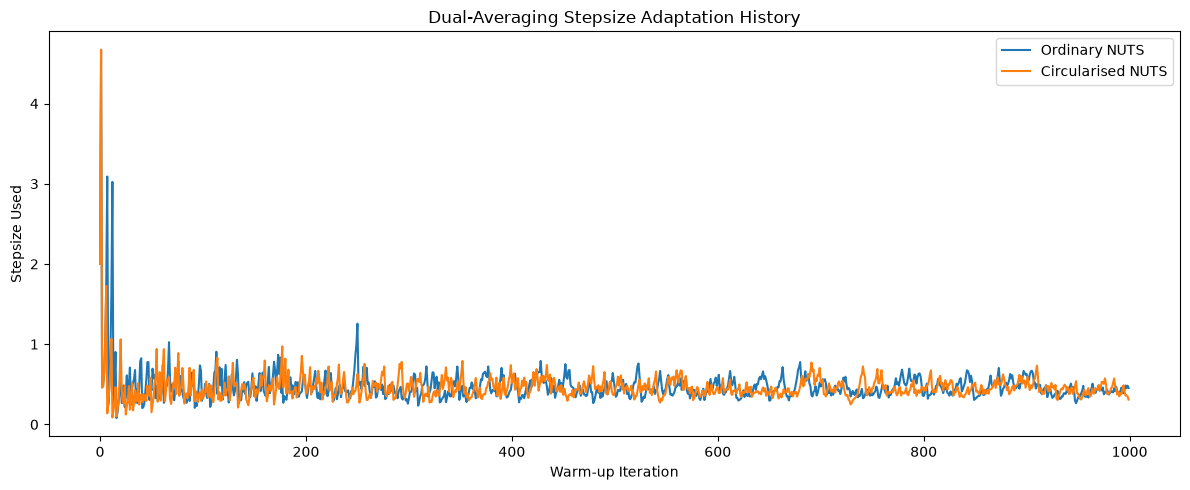

Warm-up trajectory visualisation is skipped because target_dimension != 2.


In [36]:
target_dimension = 200
target_center = np.array([0.0] * target_dimension)

# beta = 1.5
# def potential(x):
#     r2 = np.dot(x - target_center, x - target_center)

#     return (1.0 + r2) ** (beta / 2.0)


# def grad(x):
#     r2 = np.dot(x - target_center, x - target_center)

#     return (
#         beta
#         * (1.0 + r2) ** (beta / 2.0 - 1.0)
#         * (x - target_center)
#     )

def potential(x):
    return 0.5 * np.dot(x, x)

def grad(x):
    return x

ordinary_nuts_adaptation_history, circularised_nuts_adaptation_history, animation = nuts_comparison(
    initial_position=np.array([100.0] * target_dimension),
    initial_stepsize=0.1,
    target_center=target_center,
    target_potential=potential,
    target_grad=grad,
    target_dimension=target_dimension,
    selection="biased_progressive",
    n_samples=10000,
    warm_up=1000,
    target_accept=0.80,
)

# ordinary_nuts_adaptation_history.to_csv("ordinary_nuts_adaptation_history.csv")
# circularised_nuts_adaptation_history.to_csv("circularised_nuts_adaptation_history.csv")



---

## 9. Convenience constructor: one public function

This is the first version of the unified interface we discussed.


In [12]:
def make_sampler(
    *,
    potential,
    gradient,
    dimension,
    algorithm="nuts",
    stepsize=0.1,
    selection="uniform_progressive",
    center=None,
    m=1.0,
    eta=1.0,
    max_depth=20,
    max_stopping_steps=100000,
    seed=None,
    strict_radial_check=False,
):

    if selection not in ("uniform_progressive", "biased_progressive"):
        raise ValueError("Unknown selection.")
    
    target = Target(
        potential=potential,
        gradient=gradient,
        dimension=dimension,
    )  # define the target distribution using the provided potential and gradient functions, along with the specified dimension

    key = algorithm.lower().replace("_", "-")  # normalize the algorithm name to lowercase and replace underscores with hyphens for consistency
    circular = key in ("c-nuts", "cnuts", "c-gist", "cgist")  # check if the algorithm is circularised NUTS or GIST

    circulariser = None
    if circular:  # once we apply the circularised algorithms...
        circulariser = Local_Circulariser(
            center=center,
            m=m,
            eta=eta,
            strict_radial_check=strict_radial_check,
        )

    if key in ("nuts", "c-nuts", "cnuts"):  # carry the NUTS/c-NUTS algorithm
        return GeneralNUTS(
            target=target,
            stepsize=stepsize,
            circulariser=circulariser,
            selection=selection,
            max_depth=max_depth,
            seed=seed,
        )

    if key in ("gist", "c-gist", "cgist"):  # carry the GIST/c-GIST algorithm
        return GeneralGIST(
            target=target,
            stepsize=stepsize,
            circulariser=circulariser,
            selection=selection,
            max_stopping_steps=max_stopping_steps,
            seed=seed,
        )

    raise ValueError(
        "algorithm must be one of 'nuts', 'c-nuts', 'gist', 'c-gist'."
    )

We may also run a block for checking whether our proposed BPS is working in GIST, comparing with metrics in its UPS version.

In [13]:
# ============================================================
# Test GIST selection probabilities:
#
#   1. uniform progressive sampling (UPS)
#   2. biased progressive sampling (BPS)
#
# We check that:
#
#   UPS:
#       q_forward  = 1 / tau1
#       q_backward = 1 / tau2
#
#       provided alpha <= tau2.
#
#       If alpha > tau2, then q_backward = 0 because alpha is
#       outside the support of the backward trajectory.
#
#   BPS:
#       q_forward  = q_BPS(alpha | z0)
#       q_backward = q_BPS(alpha | z*)
#
#       These are state-dependent probabilities and are
#       generally different from 1/tau1 and 1/tau2,
#       and generally different from each other.
# ============================================================


def make_gist_selection_test_samplers(
    target_potential,
    target_grad,
    stepsize,
    seed=123,  # common seed for identical GIST samplers
):
    """
    Construct two otherwise identical GIST samplers:

        - UPS-GIST
        - BPS-GIST

    The same seed is used so that the initial momentum draw is
    directly comparable.
    """

    gist_uniform = make_sampler(
        potential=target_potential,
        gradient=target_grad,
        dimension=2,
        algorithm="gist",
        stepsize=stepsize,
        selection="uniform_progressive",
        seed=seed,
    )

    gist_biased = make_sampler(
        potential=target_potential,
        gradient=target_grad,
        dimension=2,
        algorithm="gist",
        stepsize=stepsize,
        selection="biased_progressive",
        seed=seed,
    )

    return {
        "UPS-GIST": gist_uniform,
        "BPS-GIST": gist_biased,
    }


def check_gist_selection_probabilities(
    target_potential,
    target_grad,
    x0,
    stepsize,
    seed=123,
):
    """
    Run one GIST transition under UPS and BPS and display
    the forward/backward selection probabilities.
    """

    samplers = make_gist_selection_test_samplers(
        target_potential=target_potential,
        target_grad=target_grad,
        stepsize=stepsize,
        seed=seed,
    )

    print()
    print("=" * 100)
    print("GIST FORWARD / BACKWARD SELECTION-PROBABILITY CHECK".center(100))
    print("=" * 100)

    print(
        f"{'Sampler':<12}"
        f"{'tau1':>8}"
        f"{'tau2':>8}"
        f"{'alpha':>8}"
        f"{'q forward':>16}"
        f"{'q backward':>16}"
        f"{'1/tau1':>16}"
        f"{'1/tau2':>16}"
    )

    print("-" * 100)

    results = {}

    for name, sampler in samplers.items():

        x_next, info = sampler.transition(
            np.asarray(x0, dtype=float)
        )

        tau1 = info["tau1_steps"]
        tau2 = info["tau2_steps"]
        alpha = info["alpha_steps"]

        q_forward = info[
            "forward_proposal_prob"
        ]

        q_backward = info[
            "backward_proposal_prob"
        ]

        uniform_forward = 1.0 / tau1

        # alpha must belong to the backward support
        # for the backward probability to be non-zero.
        uniform_backward = (
            1.0 / tau2
            if alpha <= tau2
            else 0.0
        )

        print(
            f"{name:<12}"
            f"{tau1:>8d}"
            f"{tau2:>8d}"
            f"{alpha:>8d}"
            f"{q_forward:>16.8f}"
            f"{q_backward:>16.8f}"
            f"{uniform_forward:>16.8f}"
            f"{uniform_backward:>16.8f}"
        )

        results[name] = {
            "x_next": x_next,
            "info": info,
        }

    print("=" * 100)

    # ========================================================
    # Explicit UPS check
    # ========================================================

    ups = results["UPS-GIST"]["info"]

    tau1 = ups["tau1_steps"]
    tau2 = ups["tau2_steps"]
    alpha = ups["alpha_steps"]

    qf = ups["forward_proposal_prob"]
    qb = ups["backward_proposal_prob"]

    expected_qf = 1.0 / tau1

    expected_qb = (
        1.0 / tau2
        if alpha <= tau2
        else 0.0
    )

    print()
    print("UPS sanity check")
    print("-" * 50)

    print(
        "Forward probability:"
    )

    print(
        f"  observed q_forward = {qf:.10f}"
    )

    print(
        f"  expected 1/tau1    = {expected_qf:.10f}"
    )

    print(
        "  match:",
        np.isclose(
            qf,
            expected_qf,
        ),
    )

    print()

    print(
        "Backward probability:"
    )

    print(
        f"  observed q_backward = {qb:.10f}"
    )

    print(
        f"  expected             = {expected_qb:.10f}"
    )

    print(
        "  match:",
        np.isclose(
            qb,
            expected_qb,
        ),
    )

    # ========================================================
    # BPS information
    # ========================================================

    bps = results["BPS-GIST"]["info"]

    tau1_bps = bps["tau1_steps"]
    tau2_bps = bps["tau2_steps"]
    alpha_bps = bps["alpha_steps"]

    qf_bps = bps["forward_proposal_prob"]
    qb_bps = bps["backward_proposal_prob"]

    print()
    print("BPS diagnostic")
    print("-" * 50)

    print(
        f"tau1  = {tau1_bps}"
    )

    print(
        f"tau2  = {tau2_bps}"
    )

    print(
        f"alpha = {alpha_bps}"
    )

    print()

    print(
        f"q_forward  = {qf_bps:.10f}"
    )

    print(
        f"q_backward = {qb_bps:.10f}"
    )

    print()

    print(
        f"uniform reference 1/tau1 = "
        f"{1.0 / tau1_bps:.10f}"
    )

    if alpha_bps <= tau2_bps:

        print(
            f"uniform reference 1/tau2 = "
            f"{1.0 / tau2_bps:.10f}"
        )

    else:

        print(
            "alpha > tau2, so the backward "
            "selection probability is zero."
        )

    print()

    print(
        "BPS forward and backward probabilities equal:",
        np.isclose(
            qf_bps,
            qb_bps,
        ),
    )

    return results

## 10. Smoke test: 2D standard Gaussian

In [ ]:
def make_test_samplers(target_potential, target_grad, dimension,
                       stepsize, selection="uniform_progressive"):
    """Define the samplers to be tested in the repeated realisations of the sampling experiment."""
    return {
        "NUTS": make_sampler(
            potential=target_potential,
            gradient=target_grad,
            dimension=dimension,
            algorithm="nuts",
            stepsize=stepsize,
            selection=selection,
            seed=1,
        ),

        "c-NUTS": make_sampler(
            potential=target_potential,
            gradient=target_grad,
            dimension=dimension,
            algorithm="c-nuts",
            stepsize=stepsize,
            selection=selection,
            center=np.zeros(dimension),
            seed=2,
        ),

        "GIST": make_sampler(
            potential=target_potential,
            gradient=target_grad,
            dimension=dimension,
            algorithm="gist",
            stepsize=stepsize,
            selection=selection,
            seed=3,
        ),

        "c-GIST": make_sampler(
            potential=target_potential,
            gradient=target_grad,
            dimension=dimension,
            algorithm="c-gist",
            stepsize=stepsize,
            selection=selection,
            center=np.zeros(dimension),
            seed=4,
        ),
    }


# ============================================================
# 2 x 2 KDE PLOT
# ============================================================
def plot_sampling_kde_2d(
    sample_values,
    target_potential=None,
    x0=None,
    grid_points=200,
    padding=0.10,
    kde_fill_levels=18,
    kde_line_levels=14,
    kde_cutoff=0.005,
):
    """
    Plot 2D KDE estimates for NUTS, c-NUTS, GIST and c-GIST
    in a 2 x 2 panel.

    The style is designed to match the reference figure:

        - white background;
        - coloured KDE only where the estimated density is appreciable;
        - dark contour lines for the empirical KDE;
        - light-grey contours for the true target density;
        - red cross marking the initial point x0;
        - no x1 / x2 axis labels;
        - no colour bar.

    Parameters
    ----------
    sample_values : dict
        Dictionary of sample arrays with shape (n_samples, 2).

    target_potential : callable or None
        Potential function U(x). If supplied, contours of

            pi(x) ∝ exp(-U(x))

        are overlaid.

    x0 : array-like or None
        Initial point, shown as a red cross.

    grid_points : int
        Number of grid points in each coordinate direction.

    padding : float
        Fractional padding around the total plotting range.

    kde_fill_levels : int
        Number of filled KDE contour levels.

    kde_line_levels : int
        Number of KDE contour lines.

    kde_cutoff : float
        Minimum KDE density shown, expressed as a fraction
        of the maximum KDE density.

        For example, 0.005 means densities below 0.5% of
        the maximum are left white.
    """

    sampler_order = [
        "NUTS",
        "c-NUTS",
        "GIST",
        "c-GIST",
    ]

    # ========================================================
    # Check samples
    # ========================================================

    samples_2d = {}

    for name in sampler_order:

        if name not in sample_values:
            continue

        values = np.asarray(
            sample_values[name],
            dtype=float,
        )

        if values.ndim != 2 or values.shape[1] != 2:
            raise ValueError(
                "Each sample array must have shape "
                "(n_samples, 2)."
            )

        samples_2d[name] = values

    if len(samples_2d) == 0:
        raise ValueError(
            "No sampler results were supplied."
        )

    # ========================================================
    # Initial point
    # ========================================================

    if x0 is not None:

        x0 = np.asarray(
            x0,
            dtype=float,
        )

        if x0.shape != (2,):
            raise ValueError(
                "x0 must have shape (2,)."
            )

    # ========================================================
    # Common plotting region
    # ========================================================

    pooled_samples = np.vstack(
        list(samples_2d.values())
    )

    xmin = np.min(pooled_samples[:, 0])
    xmax = np.max(pooled_samples[:, 0])

    ymin = np.min(pooled_samples[:, 1])
    ymax = np.max(pooled_samples[:, 1])

    # Make sure the initial point is visible
    if x0 is not None:

        xmin = min(xmin, x0[0])
        xmax = max(xmax, x0[0])

        ymin = min(ymin, x0[1])
        ymax = max(ymax, x0[1])

    x_range = xmax - xmin
    y_range = ymax - ymin

    if x_range == 0:
        x_range = 1.0

    if y_range == 0:
        y_range = 1.0

    xmin -= padding * x_range
    xmax += padding * x_range

    ymin -= padding * y_range
    ymax += padding * y_range

    # ========================================================
    # Common grid
    # ========================================================

    x_grid = np.linspace(
        xmin,
        xmax,
        grid_points,
    )

    y_grid = np.linspace(
        ymin,
        ymax,
        grid_points,
    )

    X, Y = np.meshgrid(
        x_grid,
        y_grid,
    )

    grid_positions = np.vstack(
        (
            X.ravel(),
            Y.ravel(),
        )
    )

    # ========================================================
    # Compute KDE for every sampler
    # ========================================================

    kde_densities = {}

    for name, values in samples_2d.items():

        kde = gaussian_kde(
            values.T
        )

        kde_density = kde(
            grid_positions
        ).reshape(
            X.shape
        )

        kde_densities[name] = kde_density

    # --------------------------------------------------------
    # Use a common maximum so all four panels have the
    # same colour-density scale
    # --------------------------------------------------------

    max_kde = max(
        np.max(density)
        for density in kde_densities.values()
    )

    # ========================================================
    # IMPORTANT:
    #
    # Do NOT start the contours at zero.
    #
    # Gaussian KDE is positive everywhere. Starting at zero
    # would therefore colour the entire panel.
    #
    # Instead, values below kde_min are left unfilled,
    # producing the required white background.
    # ========================================================

    kde_min = kde_cutoff * max_kde

    # Logarithmic spacing gives more resolution in the tails
    # and is closer to the appearance of your reference figure.
    fill_levels = np.geomspace(
        kde_min,
        max_kde,
        kde_fill_levels,
    )

    line_levels = np.geomspace(
        kde_min,
        max_kde,
        kde_line_levels,
    )

    # ========================================================
    # True target relative density
    # ========================================================

    target_density = None

    if target_potential is not None:

        target_log_density = np.empty(
            X.shape
        )

        for i in range(grid_points):

            for j in range(grid_points):

                point = np.array(
                    [
                        X[i, j],
                        Y[i, j],
                    ]
                )

                target_log_density[i, j] = (
                    -target_potential(point)
                )

        # Relative density is sufficient for contours
        target_log_density -= np.max(
            target_log_density
        )

        target_density = np.exp(
            target_log_density
        )

    # ========================================================
    # 2 x 2 figure
    # ========================================================

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(10, 9),
        sharex=True,
        sharey=True,
        facecolor="white",
    )

    axes = axes.ravel()

    for ax, name in zip(
        axes,
        sampler_order,
    ):

        if name not in samples_2d:

            ax.axis("off")
            continue

        ax.set_facecolor(
            "white"
        )

        density = kde_densities[name]

        # ----------------------------------------------------
        # Coloured empirical KDE
        #
        # Values below kde_min are not coloured, so the
        # background remains white.
        # ----------------------------------------------------

        ax.contourf(
            X,
            Y,
            density,
            levels=fill_levels,
            cmap="plasma",
            extend="max",
            alpha=0.80
        )

        # ----------------------------------------------------
        # Empirical KDE contour lines
        # ----------------------------------------------------

        ax.contour(
            X,
            Y,
            density,
            levels=line_levels,
            colors="midnightblue",
            linewidths=0.8,
        )

        # ----------------------------------------------------
        # True target contours
        # ----------------------------------------------------

        if target_density is not None:

            ax.contour(
                X,
                Y,
                target_density,
                levels=[
                    0.05,
                    0.10,
                    0.20,
                    0.35,
                    0.50,
                    0.70,
                    0.90,
                ],
                colors="0.65",
                linewidths=1.1,
                zorder=3,
            )

        # ----------------------------------------------------
        # Initial point
        # ----------------------------------------------------

        if x0 is not None:

            ax.plot(
                x0[0],
                x0[1],
                marker="x",
                markersize=9,
                markeredgewidth=2.0,
                color="red",
                zorder=5,
            )

        ax.set_title(
            name,
            fontsize=14,
        )

        ax.set_aspect(
            "equal",
            adjustable="box",
        )

        # Very light grid, or remove this completely
        # if you prefer the reference-image appearance.
        ax.grid(
            alpha=0.10
        )

    # ========================================================
    # Figure title only
    #
    # No x1 / x2 labels as requested.
    # ========================================================

    fig.suptitle(
        "Two-dimensional KDE comparison",
        fontsize=16,
        y=0.98,
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.96]
    )

    plt.show()


def run_sampler_comparison(
    target_potential,
    target_grad,
    x0,
    stepsize,
    selection,
    n_samples=10000,
    n_realisations=5,
    plot_acf=True,
    acf_coordinate=0,
    plot_kde=True,
    kde_grid_points=150,
    padding=0.1,
    kde_fill_levels=18,
    kde_line_levels=12,
    kde_cutoff=0.005
):
    """
    Run repeated comparisons of NUTS, c-NUTS, GIST and c-GIST.
    
    The function prints summary diagnostics and optionally plots:
    
        1. ACF comparison for a selected coordinate;
        2. A 2 x 2 histogram/KDE comparison for the four samplers;
        3. The true target marginal density, if supplied.

    Parameters
    ----------
    target_potential : callable
        Potential function U(x).

    target_grad : callable
        Gradient of the potential, grad U(x).

    x0 : array-like
        Initial position of the chain.

    stepsize : float
        Leapfrog step size.

    selection : str
        Choosing criteria, either "uniform_progressive" or "biased_progressive".

    n_samples : int, optional
        Number of samples per chain.

    n_realisations : int, optional
        Number of repeated realisations.

    plot_acf : bool, optional
        Whether to plot the ACF comparison after all realisations.

    acf_coordinate : int, optional
        Coordinate whose ACF is plotted. 
        Default is 0, i.e. the first coordinate.

    plot_kde : bool
        Whether to plot the 2D KDE comparison.
    
    kde_grid_points : int
        Number of grid points in each direction for the 2D KDE plot.

    padding : float
        Fractional padding around the total sample range.
    
    kde_fill_levels : int
        Number of filled KDE contour levels.
    
    kde_line_levels : int
        Number of line contour levels for the KDE.
    
    kde_cutoff : float
            Minimum KDE density shown, expressed as a fraction
            of the maximum KDE density.
    
            For example, 0.005 means densities below 0.5% of
            the maximum are left white.

    Returns
    -------
    acf_values : dict
        Dictionary containing the ACF of the selected coordinate
        for each sampler from the final realisation.

    sample_values : dict
        Full samples for each sampler from the final realisation.

    summaries : dict
        Dictionary containing the summary output for each sampler
        from the final realisation.
    """

    summaries = {}
    acf_values = {}
    sample_values = {}

    if selection not in ("uniform_progressive", "biased_progressive"):
            raise ValueError("Unknown selection.")

    for i in range(n_realisations):

        print()
        print("=" * 105)
        print(
            f"REALISATION {i + 1} / {n_realisations}"
        )
        print("=" * 105)

        print(
            f"{'Sampler':<10}"
            f"{'Mean ESS':>12}"
            f"{'CPU time (s)':>16}"
            f"{'Mean ESS/CPU s':>18}"
            f"{'Mean grad evals':>18}"
            f"{'Mean traj. steps':>19}"
        )

        print("-" * 105)

        # Re-create samplers so that each realisation uses
        # exactly the same controlled seeds.
        samplers = make_test_samplers(
            target_potential=target_potential,
            target_grad=target_grad,
            stepsize=stepsize,
            selection=selection
        )

        for name, sampler in samplers.items():

            result = sampler.sample(
                x0, n_samples=n_samples,
            )

            s = result["summary"]

            # Save summary
            summaries[name] = s

            # Save ACF of chosen coordinate
            acf_values[name] = s["acf"][acf_coordinate]

            # Save full samples
            sample_values[name] = result["samples"].copy()

            print(
                f"{name:<10}"
                f"{s['mean_ess']:>12.1f}"
                f"{s['elapsed_seconds']:>16.3f}"
                f"{s['mean_ess_per_second']:>18.1f}"
                f"{s['mean_gradient_evals']:>18.1f}"
                f"{s['mean_trajectory_steps']:>19.1f}"
            )

            del result
            gc.collect()

        # --------------------------------------------------------
        # Integrated ACF comparison
        # RUN THIS ONLY WHEN THE SEEDS FOR EACH SAMPLER ARE RANDOM!
        # --------------------------------------------------------
        
        # if plot_acf:
        
        #     plt.figure(figsize=(8, 5))
        
        #     for name, values in acf_values.items():
        
        #         lags = np.arange(len(values))
        
        #         plt.plot(
        #             lags,
        #             values,
        #             marker="o",
        #             markersize=3,
        #             label=name,
        #         )
        
        #     plt.axhline(
        #         0.0,
        #         linestyle="--",
        #         linewidth=1,
        #     )
        
        #     plt.xticks(lags)
        #     plt.xlabel("Lag")
        #     plt.ylabel("ACF")
        
        #     plt.title(
        #         f"ACF comparison for coordinate "
        #         f"{acf_coordinate + 1} "
        #         f"realisation {i+1}"
        #     )
        
        #     plt.legend()
        #     plt.grid(alpha=0.25)
        #     plt.tight_layout()
        #     plt.show()

        print("=" * 105)

    # --------------------------------------------------------
    # Integrated ACF comparison
    # --------------------------------------------------------

    if plot_acf:

        plt.figure(figsize=(8, 5))

        for name, values in acf_values.items():

            lags = np.arange(len(values))

            plt.plot(
                lags,
                values,
                marker="o",
                markersize=3,
                label=name,
            )

        plt.axhline(
            0.0,
            linestyle="--",
            linewidth=1,
        )

        plt.xticks(lags)

        plt.xlabel("Lag")
        plt.ylabel("ACF")

        plt.title(
            f"ACF comparison for coordinate "
            f"{acf_coordinate + 1}"
        )

        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


    # ========================================================
    # 2 x 2 KDE comparison
    # ========================================================
    if plot_kde:
        plot_sampling_kde_2d(
            sample_values=sample_values,
            target_potential=target_potential,
            x0=x0,
            grid_points=kde_grid_points,
            padding=padding,
            kde_fill_levels=kde_fill_levels,
            kde_line_levels=kde_line_levels,
            kde_cutoff=kde_cutoff
        )

    return acf_values, sample_values, summaries


                        GIST FORWARD / BACKWARD SELECTION-PROBABILITY CHECK                         
Sampler         tau1    tau2   alpha       q forward      q backward          1/tau1          1/tau2
----------------------------------------------------------------------------------------------------
UPS-GIST          30      10       7      0.03333333      0.10000000      0.03333333      0.10000000
BPS-GIST          30      11       8      0.03463942      0.09941530      0.03333333      0.09090909

UPS sanity check
--------------------------------------------------
Forward probability:
  observed q_forward = 0.0333333333
  expected 1/tau1    = 0.0333333333
  match: True

Backward probability:
  observed q_backward = 0.1000000000
  expected             = 0.1000000000
  match: True

BPS diagnostic
--------------------------------------------------
tau1  = 30
tau2  = 11
alpha = 8

q_forward  = 0.0346394175
q_backward = 0.0994152963

uniform reference 1/tau1 = 0.0333333333
uniform refer

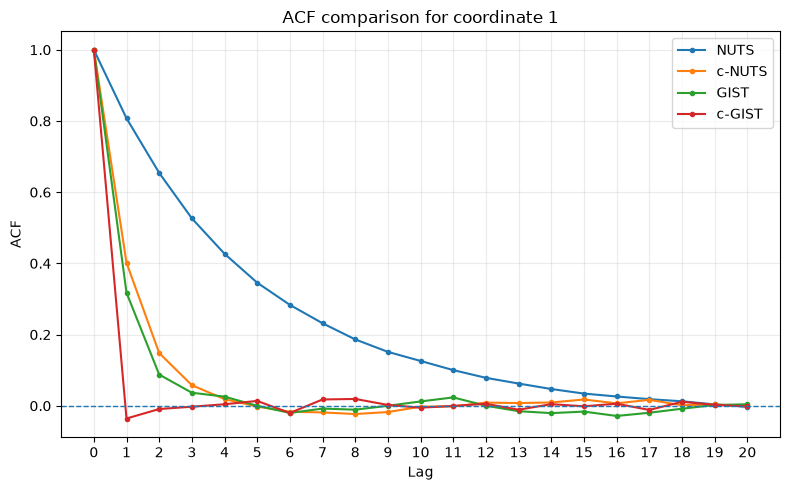

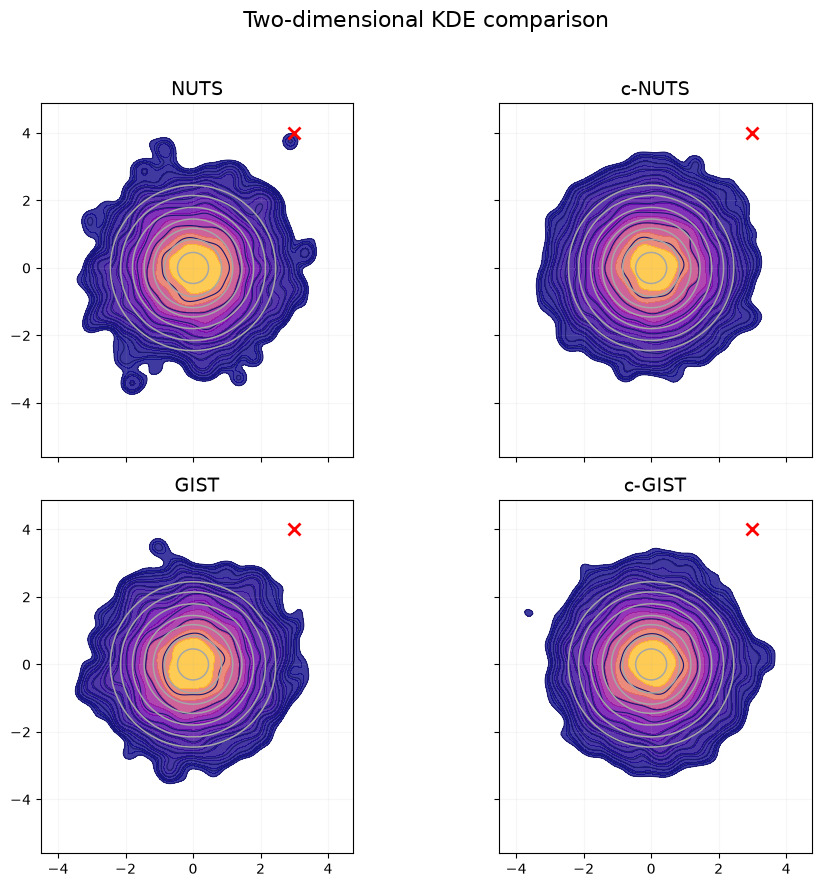


REALISATION 1 / 5
Sampler       Mean ESS    CPU time (s)    Mean ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            2104.4          11.797             178.4              28.4               13.2
c-NUTS          9965.8          22.469             443.5              64.0               31.0
GIST            5420.6          11.234             482.5              52.0               37.7
c-GIST         11619.1          16.578             700.9              65.0               47.0

REALISATION 2 / 5
Sampler       Mean ESS    CPU time (s)    Mean ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            2104.4          11.766             178.9              28.4               13.2
c-NUTS          9965.8          22.469             443.5              64.0               31.

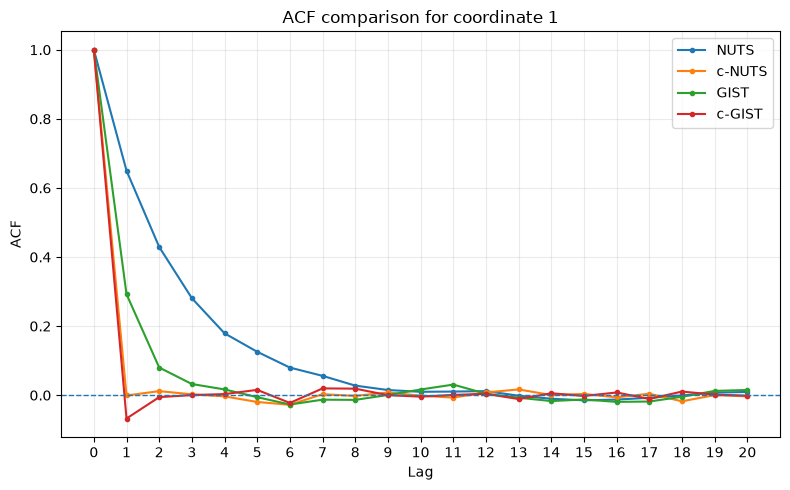

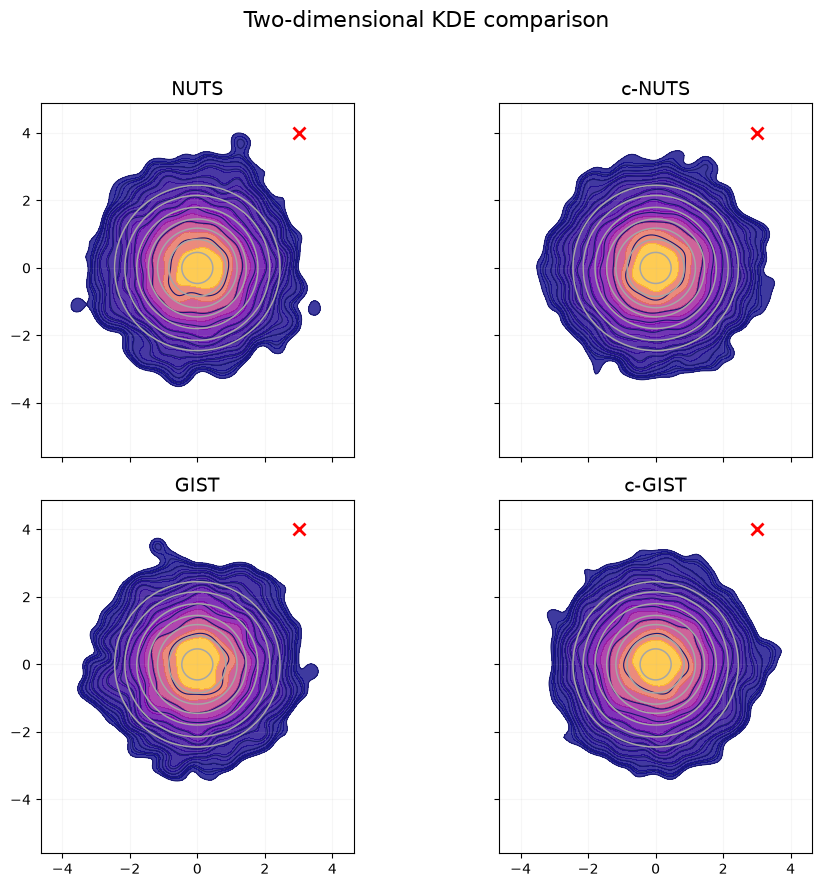

In [15]:
def gaussian_potential(x):
    return 0.5 * np.dot(x, x)

def gaussian_grad(x):
    return x

x0 = np.array([3.0, 4.0])
stepsize = 0.099  # stepsize choice seems important - for 0.099 we shall have good result!
n_samples = 10000
n_realisations = 5  # number of repeated realisations of the sampling experiment to check for consistency and stability of the results

# First check whether our BPS setting is working...
gist_selection_test = check_gist_selection_probabilities(
    target_potential=gaussian_potential,
    target_grad=gaussian_grad,
    x0=x0,
    stepsize=stepsize,
    seed=123,
)

# we show both the uniform progressive and biased progressive sampling result
acf_values, sample_values, summaries = run_sampler_comparison(target_potential=gaussian_potential,
                       target_grad=gaussian_grad,
                       x0=x0,
                       stepsize=stepsize,
                       selection="uniform_progressive",
                       n_samples=n_samples,
                       n_realisations=n_realisations,
                       plot_acf=True, acf_coordinate=0,
                       plot_kde=True, kde_grid_points=150)

acf_values, sample_values, summaries = run_sampler_comparison(target_potential=gaussian_potential,
                       target_grad=gaussian_grad,
                       x0=x0,
                       stepsize=stepsize,
                       selection="biased_progressive",
                       n_samples=n_samples,
                       n_realisations=n_realisations,
                       plot_acf=True, acf_coordinate=0,
                       plot_kde=True, kde_grid_points=150)

## 11. Non-Gaussian radial example


For
$$
U(x)=(1+\|x\|^2)^{\beta/2},
\qquad
\nabla U(x)=\beta (1+\|x\|^{2})^{\beta/2 - 1}x,
$$
the inferred frozen scalar coefficient is exactly
$$
\kappa_0=\beta (1+\|x_0\|^{2})^{\beta/2 - 1},
$$


                        GIST FORWARD / BACKWARD SELECTION-PROBABILITY CHECK                         
Sampler         tau1    tau2   alpha       q forward      q backward          1/tau1          1/tau2
----------------------------------------------------------------------------------------------------
UPS-GIST          35      12       8      0.02857143      0.08333333      0.02857143      0.08333333
BPS-GIST          35      13       9      0.02936521      0.08320710      0.02857143      0.07692308

UPS sanity check
--------------------------------------------------
Forward probability:
  observed q_forward = 0.0285714286
  expected 1/tau1    = 0.0285714286
  match: True

Backward probability:
  observed q_backward = 0.0833333333
  expected             = 0.0833333333
  match: True

BPS diagnostic
--------------------------------------------------
tau1  = 35
tau2  = 13
alpha = 9

q_forward  = 0.0293652148
q_backward = 0.0832070951

uniform reference 1/tau1 = 0.0285714286
uniform refer

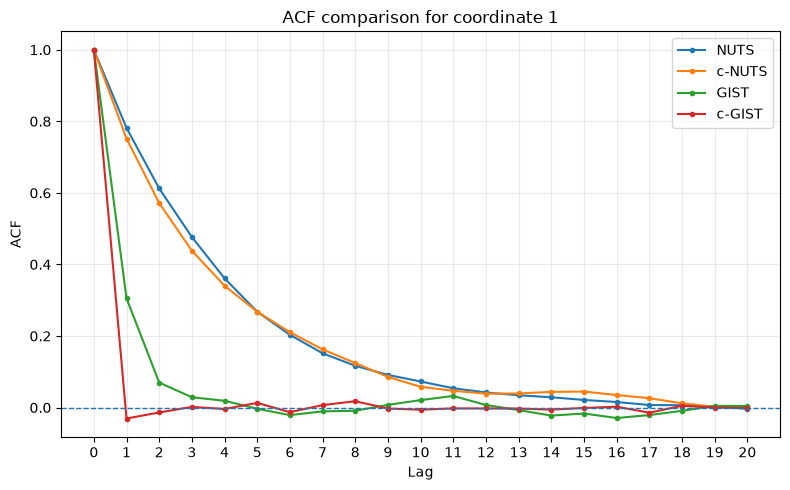

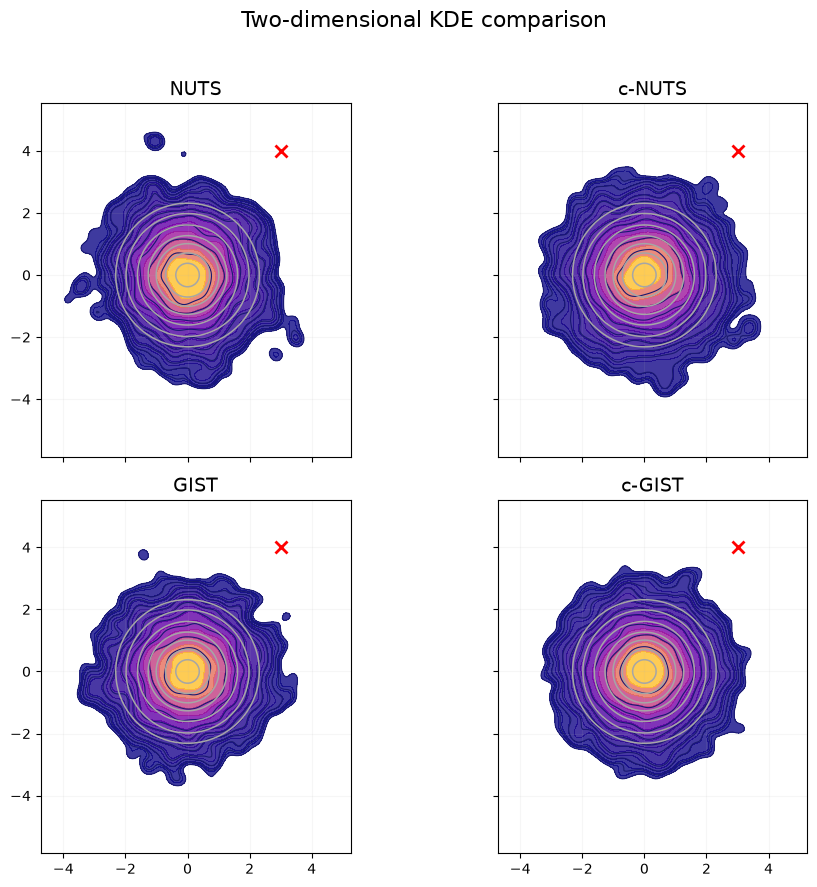


REALISATION 1 / 5
Sampler       Mean ESS    CPU time (s)    Mean ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            2097.4          12.391             169.3              28.0               13.0
c-NUTS          2807.5          16.359             171.6              34.2               16.1
GIST            5669.1          11.828             479.3              49.2               35.5
c-GIST         11124.1          16.828             661.0              60.5               43.6

REALISATION 2 / 5
Sampler       Mean ESS    CPU time (s)    Mean ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            2097.4          12.297             170.6              28.0               13.0
c-NUTS          2807.5          16.422             171.0              34.2               16.

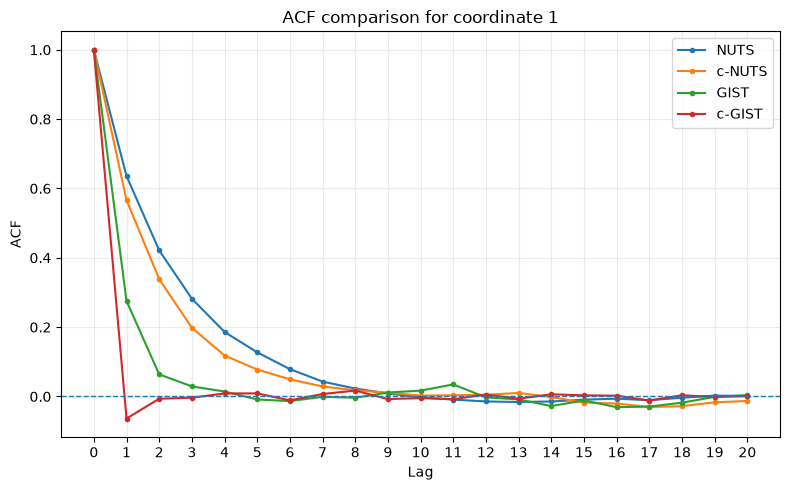

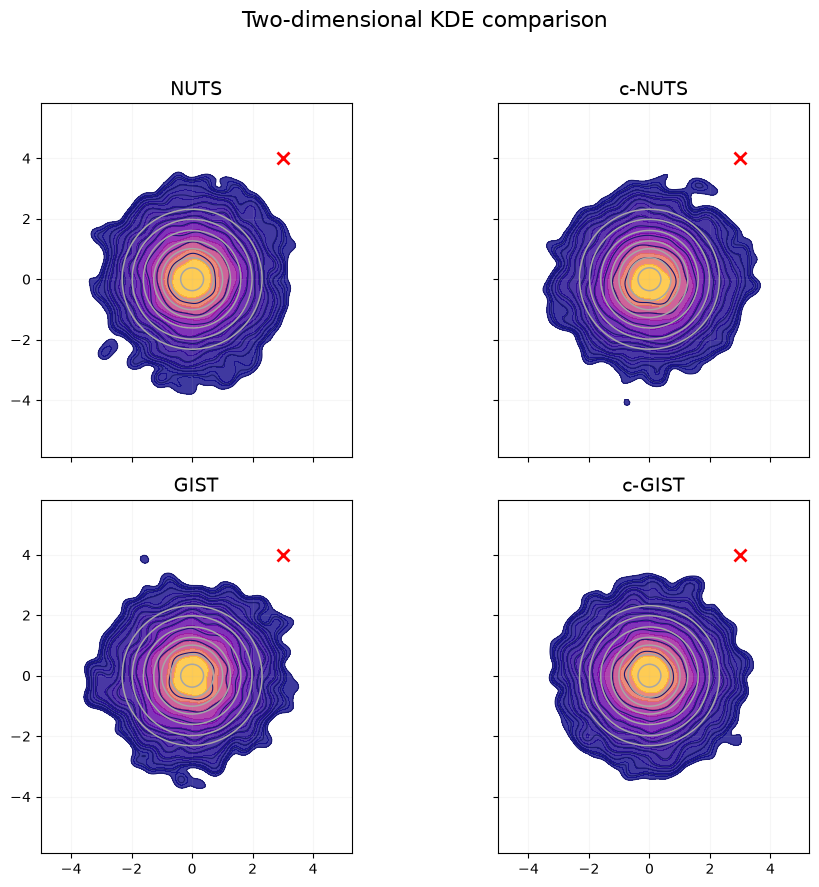

In [16]:
beta = 1.5  # beta is a number that between 1 and 2

def beta1_potential(x):
    r2 = np.dot(x, x)

    return (1.0 + r2) ** (beta / 2.0)


def beta1_grad(x):
    r2 = np.dot(x, x)

    return (
        beta
        * (1.0 + r2) ** (beta / 2.0 - 1.0)
        * x
    )

x0 = np.array([3.0, 4.0])
stepsize = 0.099  # stepsize choice seems important - for 0.099 we shall have good result!
n_samples = 10000
n_realisations = 5  # number of repeated realisations of the sampling experiment to check for consistency and stability of the results

# First check whether our BPS setting is working...
gist_selection_test = check_gist_selection_probabilities(
    target_potential=beta1_potential,
    target_grad=beta1_grad,
    x0=x0,
    stepsize=stepsize,
    seed=123,
)

# we show both the uniform progressive and biased progressive sampling result
acf_values, sample_values, summaries = run_sampler_comparison(target_potential=beta1_potential,
                       target_grad=beta1_grad,
                       x0=x0,
                       stepsize=stepsize,
                       selection="uniform_progressive",
                       n_samples=n_samples,
                       n_realisations=n_realisations,
                       plot_acf=True, acf_coordinate=0,
                       plot_kde=True, kde_grid_points=150)

acf_values, sample_values, summaries = run_sampler_comparison(target_potential=beta1_potential,
                       target_grad=beta1_grad,
                       x0=x0,
                       stepsize=stepsize,
                       selection="biased_progressive",
                       n_samples=n_samples,
                       n_realisations=n_realisations,
                       plot_acf=True, acf_coordinate=0,
                       plot_kde=True, kde_grid_points=150)

For the $\beta_1$ family, the local circularisation uses a constant isotropic curvature $\kappa_0$, whereas the true target has both a radius-dependent curvature scale and a radius-dependent distinction between radial and tangential curvature. Consequently, the frozen matrix $W$ becomes less representative of the true trajectory geometry as the trajectory moves away from $x_0$. The circularised U-turn criterion may therefore extend the NUTS tree without producing a proportional reduction in autocorrelation. Because NUTS expands trajectories by doubling, even a modest delay in stopping can incur a substantial additional computational cost, resulting in a lower ESS per CPU second.

**HOWEVER, BPS DOES SOLVE THIS PROBLEM AND RESULT SIMILAR ESS PER SECOND FOR BOTH NUTS AND c-NUTS, WHILE WE STILL SEE A GENERAL FAVOURABLE c-GIST PERFORMANCE STILL!**

**BPS enables to reduces the ACF and increases the ESS (roughly doubled).**


For
$$
U(x)=\frac{1}{\beta}\|x\|^\beta,
\qquad
\nabla U(x)=\|x\|^{\beta-2}x,
$$
the inferred frozen scalar coefficient is exactly
$$
\kappa_0=\|x_0\|^{\beta-2},
$$
so this reproduces the local frozen construction from the previous GIST notebook.



                        GIST FORWARD / BACKWARD SELECTION-PROBABILITY CHECK                         
Sampler         tau1    tau2   alpha       q forward      q backward          1/tau1          1/tau2
----------------------------------------------------------------------------------------------------
UPS-GIST          42      15      10      0.02380952      0.06666667      0.02380952      0.06666667
BPS-GIST          42      16      11      0.02437738      0.06661783      0.02380952      0.06250000

UPS sanity check
--------------------------------------------------
Forward probability:
  observed q_forward = 0.0238095238
  expected 1/tau1    = 0.0238095238
  match: True

Backward probability:
  observed q_backward = 0.0666666667
  expected             = 0.0666666667
  match: True

BPS diagnostic
--------------------------------------------------
tau1  = 42
tau2  = 16
alpha = 11

q_forward  = 0.0243773821
q_backward = 0.0666178312

uniform reference 1/tau1 = 0.0238095238
uniform refe

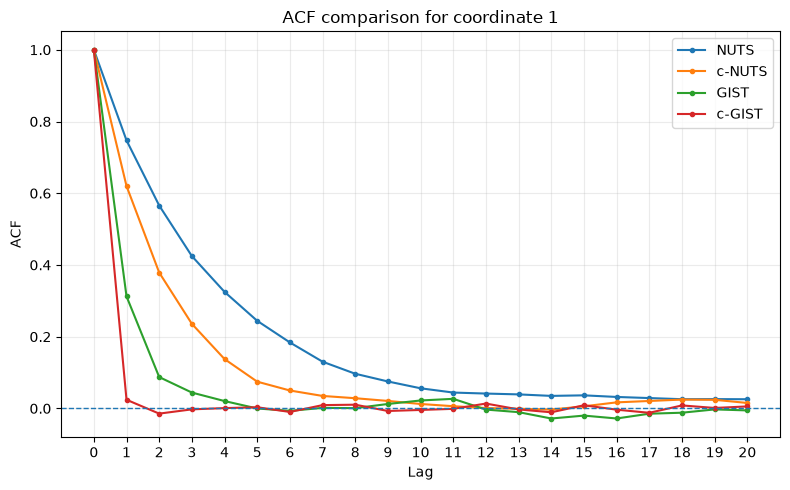

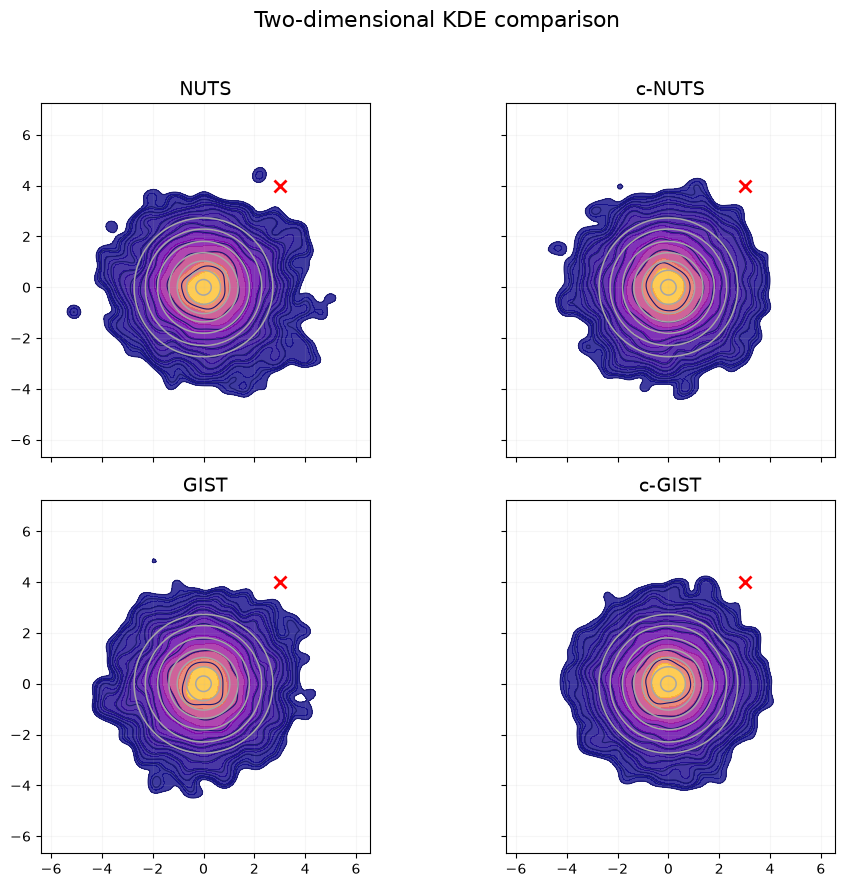


REALISATION 1 / 5
Sampler       Mean ESS    CPU time (s)    Mean ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            2935.4          14.344             204.6              36.8               17.4
c-NUTS          4575.8          20.266             225.8              50.0               24.0
GIST            5456.8          13.656             399.6              58.9               42.8
c-GIST          9772.9          18.953             515.6              70.7               51.5

REALISATION 2 / 5
Sampler       Mean ESS    CPU time (s)    Mean ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            2935.4          14.250             206.0              36.8               17.4
c-NUTS          4575.8          20.031             228.4              50.0               24.

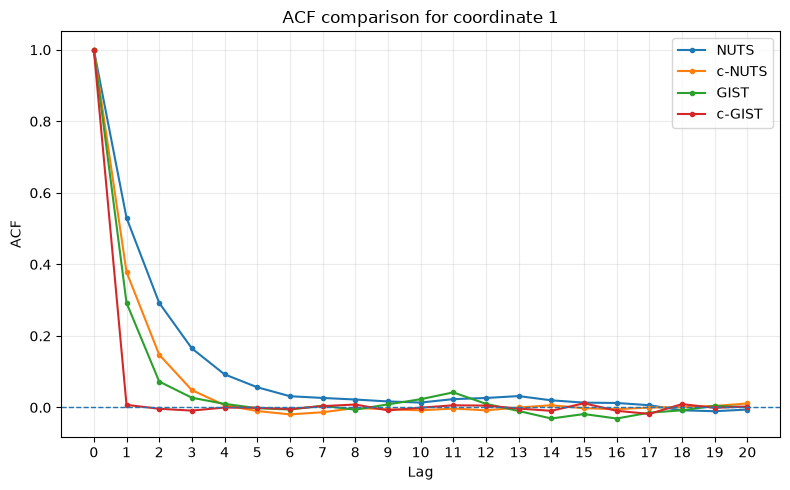

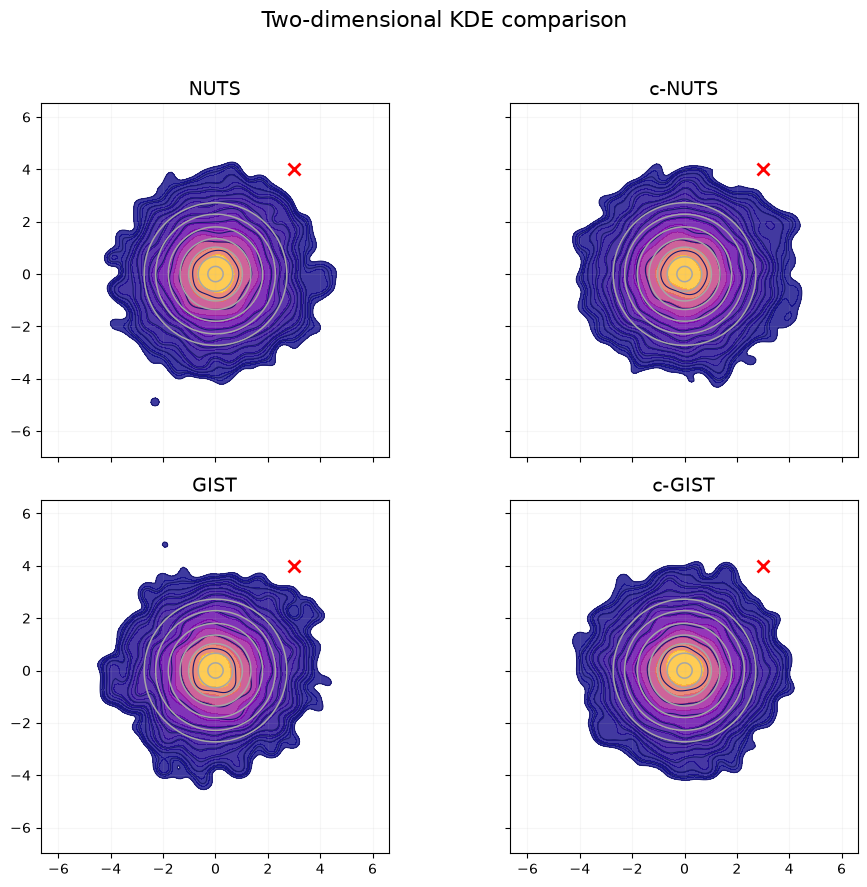

In [17]:

beta = 1.5  # beta is a number that between 1 and 2

def beta2_potential(x):
    r2 = np.dot(x, x)
    return (r2 ** (beta / 2.0)) / beta

def beta2_grad(x):
    r2 = np.dot(x, x)
    if r2 == 0:
        return np.zeros_like(x)
    return (r2 ** (beta / 2.0 - 1.0)) * x

x0 = np.array([3.0, 4.0])
stepsize = 0.099  # stepsize choice seems important - for 0.099 we shall have good result!
n_samples = 10000
n_realisations = 5  # number of repeated realisations of the sampling experiment to check for consistency and stability of the results

# First check whether our BPS setting is working...
gist_selection_test = check_gist_selection_probabilities(
    target_potential=beta2_potential,
    target_grad=beta2_grad,
    x0=x0,
    stepsize=stepsize,
    seed=123,
)

# we show both the uniform progressive and biased progressive sampling result
acf_values, sample_values, summaries = run_sampler_comparison(target_potential=beta2_potential,
                       target_grad=beta2_grad,
                       x0=x0,
                       stepsize=stepsize,
                       selection="uniform_progressive",
                       n_samples=n_samples,
                       n_realisations=n_realisations,
                       plot_acf=True, acf_coordinate=0,
                       plot_kde=True, kde_grid_points=150)

acf_values, sample_values, summaries = run_sampler_comparison(target_potential=beta2_potential,
                       target_grad=beta2_grad,
                       x0=x0,
                       stepsize=stepsize,
                       selection="biased_progressive",
                       n_samples=n_samples,
                       n_realisations=n_realisations,
                       plot_acf=True, acf_coordinate=0,
                       plot_kde=True, kde_grid_points=150)

Isotropic Student-$t$ distribution.


REALISATION 1 / 5
Sampler       Mean ESS    CPU time (s)    Mean ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            1399.9           5.047             277.4              34.1               16.1
c-NUTS          1600.4           8.734             183.2              46.3               22.1
GIST            4729.2           7.406             638.5              58.2               42.8
c-GIST          9030.4          11.438             789.5              70.1               51.5

REALISATION 2 / 5
Sampler       Mean ESS    CPU time (s)    Mean ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            1399.9           5.000             280.0              34.1               16.1
c-NUTS          1600.4           8.672             184.6              46.3               22.

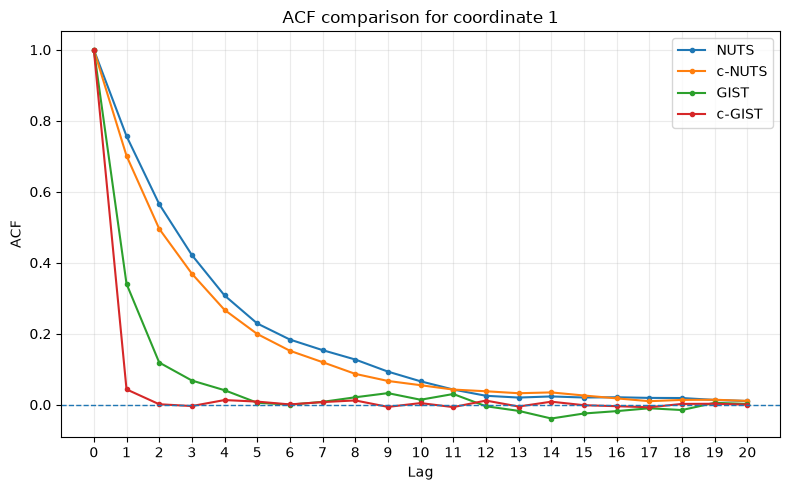

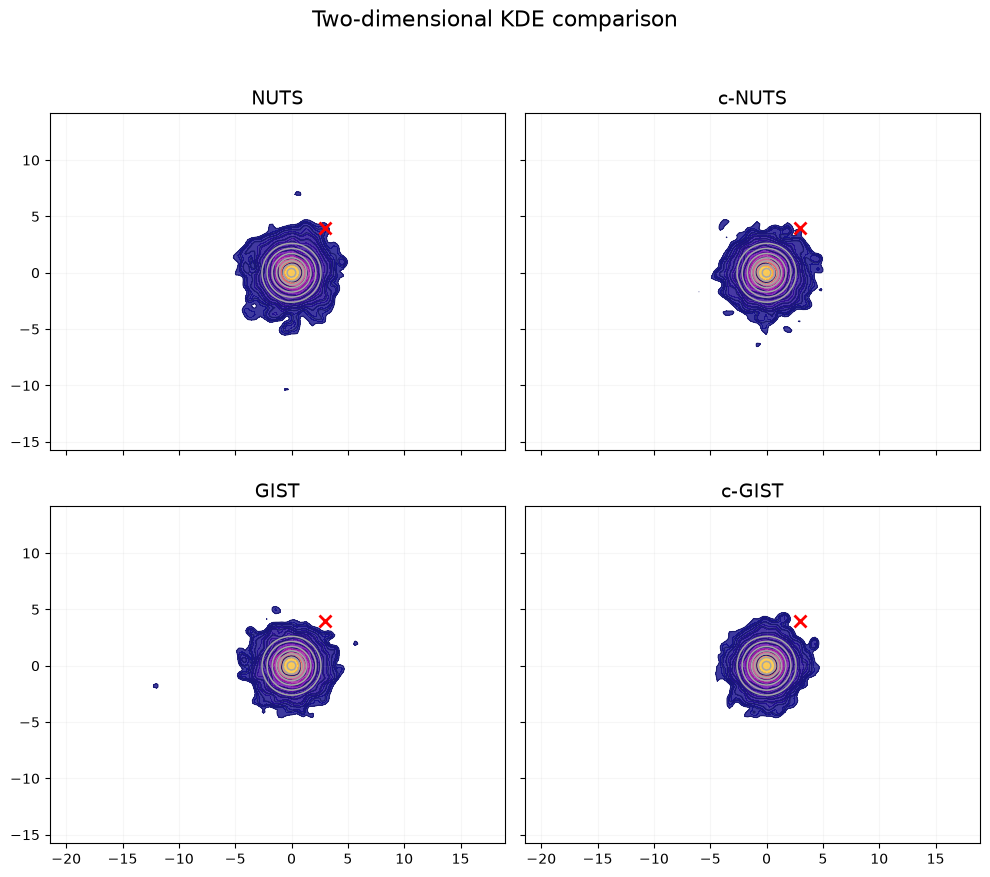


REALISATION 1 / 5
Sampler       Mean ESS    CPU time (s)    Mean ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            2481.4          13.984             177.4              34.1               16.1
c-NUTS          3156.8          19.391             162.8              45.9               21.9
GIST            5094.5          13.953             365.1              58.3               42.3
c-GIST          9357.9          19.250             486.1              70.0               51.0

REALISATION 2 / 5
Sampler       Mean ESS    CPU time (s)    Mean ESS/CPU s   Mean grad evals   Mean traj. steps
---------------------------------------------------------------------------------------------------------
NUTS            2481.4          13.984             177.4              34.1               16.1
c-NUTS          3156.8          19.438             162.4              45.9               21.

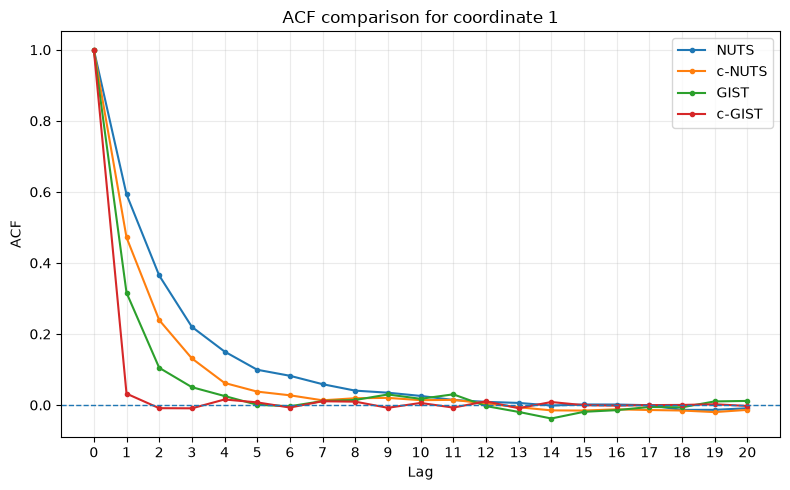

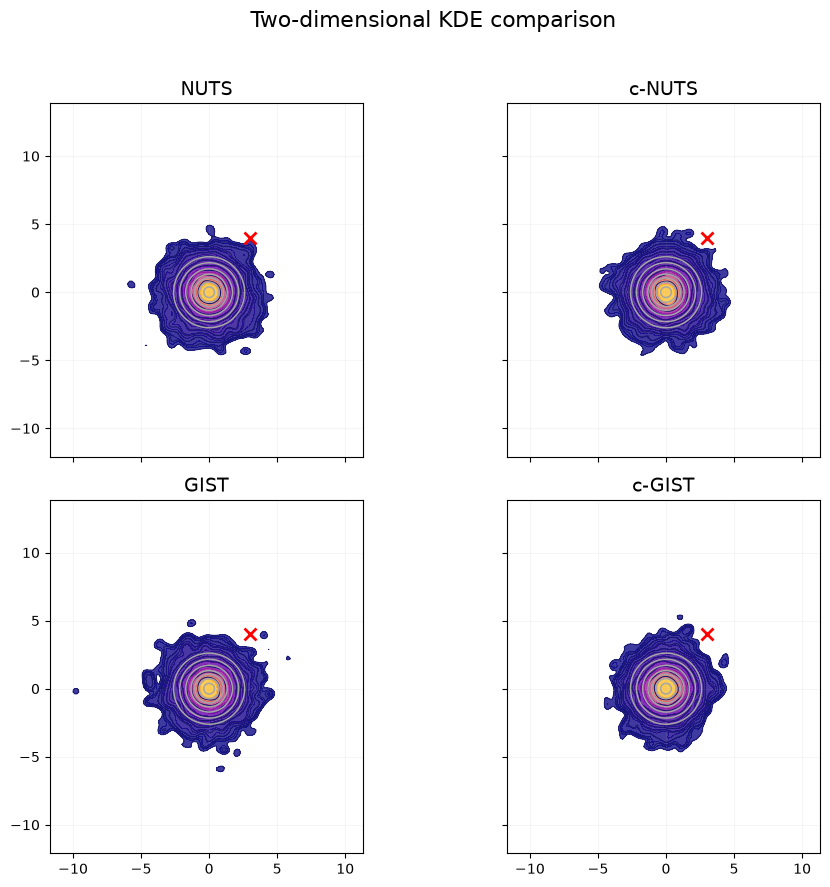

In [18]:
nu = 5.0
d = 2

def student_t_potential(x):
    r2 = np.dot(x, x)
    return 0.5 * (nu + d) * np.log1p(r2 / nu)

def student_t_grad(x):
    r2 = np.dot(x, x)
    return ((nu + d) / (nu + r2)) * x

x0 = np.array([3.0, 4.0])
stepsize = 0.099  # stepsize choice seems important - for 0.099 we shall have good result!
n_samples = 10000
n_realisations = 5  # number of repeated realisations of the sampling experiment to check for consistency and stability of the results

# we show both the uniform progressive and biased progressive sampling result
acf_values, sample_values, summaries = run_sampler_comparison(target_potential=student_t_potential,
                       target_grad=student_t_grad,
                       x0=x0,
                       stepsize=stepsize,
                       selection="uniform_progressive",
                       n_samples=n_samples,
                       n_realisations=n_realisations,
                       plot_acf=True, acf_coordinate=0,
                       plot_kde=True, kde_grid_points=150)

acf_values, sample_values, summaries = run_sampler_comparison(target_potential=student_t_potential,
                       target_grad=student_t_grad,
                       x0=x0,
                       stepsize=stepsize,
                       selection="biased_progressive",
                       n_samples=n_samples,
                       n_realisations=n_realisations,
                       plot_acf=True, acf_coordinate=0,
                       plot_kde=True, kde_grid_points=150)


## 13. Next implementation steps

The most important next extensions are:

1. verify each transition against the two previous notebooks on Gaussian/radial targets;
2. decide the general non-radial local circularisation rule (likely a separate circulariser object rather than hard-coding it into the sampler);
3. add optional diagonal/dense mass matrices;
4. add dual-averaging step-size adaptation during warm-up;
5. add ACF plotting and a compact comparison table across all four samplers;
6. later add a PosteriorDB/BridgeStan target backend.


In [ ]:
class DualAveragingStepSize:
    """
    Nesterov dual-averaging adaptation of the leapfrog step size.

    Based on Hoffman & Gelman (2014).

    Parameters
    ----------
    initial_stepsize : float
        Initial step size epsilon_0.

    target_accept : float
        Target mean acceptance statistic delta.

    gamma : float
        Controls the scale of adaptation.

    t0 : float
        Stabilises adaptation during early iterations.

    kappa : float
        Controls decay of the averaging weights.
    """

    def __init__(
        self,
        initial_stepsize: float,
        target_accept: float = 0.65,
        gamma: float = 0.05,
        t0: float = 10.0,
        kappa: float = 0.75,
    ):
        if initial_stepsize <= 0 or not np.isfinite(initial_stepsize):
            raise ValueError("initial_stepsize must be positive and finite.")

        if not (0.0 < target_accept < 1.0):
            raise ValueError("target_accept must lie in (0, 1).")

        if gamma <= 0:
            raise ValueError("gamma must be positive.")

        if t0 < 0:
            raise ValueError("t0 must be non-negative.")

        if not (0.5 < kappa <= 1.0):
            raise ValueError("kappa must lie in (0.5, 1].")

        self.initial_stepsize = float(initial_stepsize)
        self.target_accept = float(target_accept)
        self.gamma = float(gamma)
        self.t0 = float(t0)
        self.kappa = float(kappa)

        # Hoffman--Gelman shrinkage point
        self.mu = np.log(10.0 * self.initial_stepsize)

        # Dual-averaging state
        self.iteration = 0
        self.H_bar = 0.0

        self.log_stepsize = np.log(self.initial_stepsize)
        self.log_stepsize_bar = np.log(self.initial_stepsize)

    def update(self, acceptance_statistic: float) -> float:
        """
        Perform one dual-averaging update.

        Parameters
        ----------
        acceptance_statistic : float
            Mean acceptance statistic from the most recent iteration.

        Returns
        -------
        stepsize : float
            Step size to use in the NEXT warm-up iteration.
        """

        acceptance_statistic = float(acceptance_statistic)

        if not np.isfinite(acceptance_statistic):
            raise ValueError("acceptance_statistic must be finite.")

        acceptance_statistic = np.clip(acceptance_statistic, 0.0, 1.0)

        self.iteration += 1
        m = self.iteration  # update number of iterations

        # ------------------------------------------------------
        # H_bar update
        # ------------------------------------------------------

        eta_H = 1.0 / (m + self.t0)

        self.H_bar = (
            (1.0 - eta_H) * self.H_bar
            +
            eta_H
            * (
                self.target_accept
                - acceptance_statistic
            )
        )

        # ------------------------------------------------------
        # Current, unsmoothed step size epsilon_m
        # ------------------------------------------------------
        self.log_stepsize = (
            self.mu - (np.sqrt(m) / self.gamma) * self.H_bar
        )

        # ------------------------------------------------------
        # Smoothed step size epsilon_bar_m
        # ------------------------------------------------------
        eta_bar = m ** (-self.kappa)
        self.log_stepsize_bar = (
            eta_bar * self.log_stepsize +
            (1.0 - eta_bar) * self.log_stepsize_bar
        )

        return float(np.exp(self.log_stepsize))

    def current_stepsize(self) -> float:
        """Current unsmoothed warm-up step size."""
        return float(np.exp(self.log_stepsize))

    def final_stepsize(self) -> float:
        """
        Smoothed step size to use after warm-up.
        """
        return float(np.exp(self.log_stepsize_bar))